# Footprints before the 8-K

**Gator Quant Hacks 2026 · Massive Challenge · Trade the 8-K**

## The idea in one paragraph

Material corporate events leak before they are public, and the people who know trade options. That
leaves a **footprint** in the chain in the sessions before the announcement: abnormal volume, tilted to
out-of-the-money calls or puts, with the risk reversal moving the same way. The 8-K arrives days later
and tells everyone *what* happened. We ask what the footprint is worth once the 8-K category says the
news was the leakable kind, against the same footprint on ordinary days.

## Two studies, and why there are two

**Study 1 · pre-registered** (written before any data was pulled). A bullish footprint ahead of a
leak-prone 8-K predicts drift up, traded with **1 · Long call**; a bearish one predicts drift down,
traded with **3 · Protective put**.

**Study 2 · the mechanism the first run suggested.** The first run (recorded verbatim in Appendix A)
showed the long call *losing* after a bullish footprint, in-sample and out-of-sample. One economic
reading: the footprint is **visible**, call buyers bid up implied volatility before the news, and the
call is expensive by the time the 8-K is out. If so, the footprint is a signal to *sell* what the crowd
overpaid for: **bullish footprint → 2 · Covered call**; and on the bearish side the question is whether
the **protective put's hedge leg** pays: **bearish footprint → 3 · Protective put**, measured on the put.
Section 9 tests the mechanism directly before trusting the trade.

Study 2 was formed after the first run's in-sample *and* out-of-sample numbers were seen, so this
notebook's out-of-sample window is a consistency check for it, not a test. The sealed window is the
only untouched data; our predictions for it are in section 15, written before it is run.

## Findings

**A careful null with a short decay curve.** On 520 leak-prone 8-Ks against 764 ordinary days:

1. **Footprints before leak-prone 8-Ks are barely more common than on ordinary days**: 22% of events
   cross the abnormal-volume threshold against 20% of ordinary days (section 7). Whatever leaks, most of
   it does not show up in daily option volume on the 100 largest names.
2. **Its trading value is short-lived.** After a bullish footprint the long call beats quiet flow, net
   of ordinary days, by about +0.6% and +1.0% of spot at 2 and 3 sessions (95% intervals exclude zero),
   and the edge is gone by 10 sessions (section 13's decay curves); the stock's own signed drift has the
   same shape. That is the shape P2 of the pre-registration predicted, **in-sample only**: out-of-sample
   the 2-3 session edge does not reappear (about −0.5%, 17 events). It is the sealed window's hypothesis,
   not a result.
3. **None of the five headline numbers (averaged over 5, 10 and 21 sessions) is significant**, in-sample
   or out-of-sample, after a week-clustered bootstrap, a permutation test and a Holm correction.
4. **The first run's strong-looking results did not survive** a larger, rule-based category pool, more
   ordinary days and proper inference. Appendix A records them and section 12 reproduces them; they were
   a small-sample artefact.
5. **The Study 2 mechanism is not there**: implied vol at entry is not significantly higher after a
   bullish footprint, and the implied-vol part of the long call's P&L is a few basis points.
6. **Not tradeable as specified**: on the legs measured, real closing spreads cost more than the gross
   edge at 10 sessions, and the 5% OTM legs trade tens of contracts a day. Section 14 says what a version that could be traded
   would have to look like.

## The design: a 2 × 2 against ordinary days

|  | Abnormal directional footprint | Quiet options flow |
|---|---|---|
| **Leak-prone 8-K follows** | **A** | **B** |
| **Ordinary day, same names** | **C** | **D** |

Every trade result is the difference-in-differences **(A − B) − (C − D)**: what the footprint is worth
before a leak-prone 8-K, net of what the same footprint is worth on any day. On top of that:
negative-control categories (scheduled earnings, director appointments, equity grants, charter
amendments), a permutation test and a week-clustered bootstrap on five pre-specified headline numbers
with a Holm correction, a split by year, a one-knob-at-a-time sensitivity grid, real closing spreads
from options quotes, and `run_study(start, end)` for the judges.

## What changed after the first run, and why

| Change | Reason (decided without looking at its effect) |
|---|---|
| Entry at the close of the session **after** the filing (`ENTRY = "next"`) | Filings accepted 16:00-17:30 ET carry that day's date, so a `t_0` close entry is look-ahead. Massive has no acceptance timestamps, and this rule is tradeable for every filing |
| Category pool from an explicit rule, 9 → 34 tags | Rule: material, not on a calendar, known to insiders or advisers before the announcement. Routine appointments and scheduled events are out. The first 9 were examples of the rule |
| Footprint coverage fixes | 31 of 318 events had no footprint (thin expiry ladders on BK, NEE, AMT; spot recovery on one expiry). Now the nearest listed expiry and the next expiry are tried |
| Ordinary days 400 → 800 | Cells C were 9-20 events; the 2 × 2 needs them |
| Headline numbers, permutation test, Holm, week clusters | Too many cells with stars in the first run; five pre-specified numbers replace them |

## How to run

1. `MASSIVE_API_KEY=...` in `.env` beside this notebook (same as the starter).
2. `SMOKE_TEST = True` in section 2 for a few-minute plumbing check; `False` for the real run.
3. Run all. Responses are cached in `.massive_cache/` (shared with the starter notebook).
   Judges: set the sealed dates and `RUN_HOLDOUT = True` in section 2.

## 1 · API client

Same as the starter (`api_get` caches every response on disk by URL, `api_get_all` follows pagination),
with two changes: one HTTP session per thread, and atomic cache writes, so `pmap` can fetch in parallel.

In [1]:
import os, json, time, hashlib, re, math, threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from pandas.tseries.holiday import (AbstractHolidayCalendar, Holiday, nearest_workday, USMartinLutherKingJr,
                                    USPresidentsDay, GoodFriday, USMemorialDay, USLaborDay, USThanksgivingDay)
from pandas.tseries.offsets import CustomBusinessDay

BASE_URL = "https://api.massive.com"


def load_api_key(name: str = "MASSIVE_API_KEY") -> str:
    """Environment first, then a `.env` file beside the notebook, then a prompt. Never paste a key into a cell."""
    key = (os.environ.get(name) or "").strip()
    env_file = Path(".env")
    if not key and env_file.exists():
        for line in env_file.read_text().splitlines():
            if line.strip().startswith(f"{name}="):
                key = line.split("=", 1)[1].strip().strip('"').strip("'")
    if not key:
        key = getpass(f"{name} (https://massive.com/dashboard/keys): ").strip()
    return key


API_KEY = load_api_key()
_local = threading.local()


def _session() -> requests.Session:
    s = getattr(_local, "session", None)
    if s is None:
        s = requests.Session()
        s.headers["Authorization"] = f"Bearer {API_KEY}"
        _local.session = s
    return s


CACHE_DIR = Path(".massive_cache")
CACHE_DIR.mkdir(exist_ok=True)


def api_get(path_or_url: str, params: dict | None = None) -> dict:
    """GET one page from the Massive REST API. Cached on disk by the full URL, so reruns are free."""
    url = path_or_url if path_or_url.startswith("http") else BASE_URL + path_or_url
    full_url = requests.Request("GET", url, params=params).prepare().url
    cache_file = CACHE_DIR / (hashlib.sha1(full_url.encode()).hexdigest() + ".json")
    if cache_file.exists():
        return json.loads(cache_file.read_text())
    for attempt in range(10):
        resp = _session().get(full_url, timeout=60)
        if resp.status_code in (429, 500, 502, 503, 504):
            retry_after = resp.headers.get("Retry-After", "")
            time.sleep(float(retry_after) if retry_after.isdigit() else min(2 ** attempt, 20))
            continue
        break
    resp.raise_for_status()
    payload = resp.json()
    tmp = cache_file.with_suffix(f".{threading.get_ident()}.tmp")
    tmp.write_text(json.dumps(payload))
    tmp.replace(cache_file)
    return payload


def api_get_all(path: str, params: dict | None = None, max_pages: int = 500) -> list[dict]:
    """Follow `next_url` pagination and return every result row."""
    payload = api_get(path, params)
    rows = list(payload.get("results") or [])
    pages = 1
    while payload.get("next_url") and pages < max_pages:
        payload = api_get(payload["next_url"])
        rows.extend(payload.get("results") or [])
        pages += 1
    return rows


def pmap(fn, items, label: str = "", every: int = 50) -> list:
    """Run `fn` over `items` on N_THREADS threads, keeping order. A failed item becomes None (first errors printed)."""
    items = list(items)
    out, errors, t0 = [None] * len(items), 0, time.time()
    with ThreadPoolExecutor(N_THREADS) as ex:
        futures = {ex.submit(fn, it): i for i, it in enumerate(items)}
        for n, f in enumerate(as_completed(futures), 1):
            try:
                out[futures[f]] = f.result()
            except Exception as e:
                errors += 1
                if errors <= 3:
                    print(f"  {label}: item {futures[f]} failed: {type(e).__name__}: {e}")
            if label and n % every == 0:
                print(f"  {label}: {n}/{len(items)} ({time.time() - t0:.0f}s)")
    if label:
        print(f"  {label}: {len(items)} done in {time.time() - t0:.0f}s, {errors} failed")
    return out


print(f"API key loaded (ends {API_KEY[-4:]}); cache at {CACHE_DIR.resolve()}")

API key loaded (ends jNOD); cache at /Users/lalitboyapati/Documents/projects/GQHacks/massive/gqh-massive-8k-starter/.massive_cache


## 2 · Configuration

Everything a team may change is here. `HORIZONS` are fixed by the organizers. The footprint parameters
have neighbours in their `_GRID` lists; section 10 walks them.

In [2]:
SMOKE_TEST = False          # True: a few-minute run on a handful of events to check the plumbing (numbers meaningless)

# ---- Categories ------------------------------------------------------------------------------------
# Leak-prone = material, not on a calendar, and known to insiders or advisers before it is announced.
LEAK_TAGS = [
    # deals
    "acquisition_agreement", "merger_agreement", "divestiture_agreement", "joint_venture_agreement", "tender_offer",
    "deal_termination", "partnership_or_collaboration", "significant_contract_award",
    # leadership changes that are not routine
    "ceo_appointment", "ceo_departure", "cfo_departure", "executive_officer_departure",
    # outlook, strategy, restructuring
    "guidance_issuance_or_update", "guidance_withdrawal", "strategic_initiative", "restructuring_plan",
    "business_line_exit", "workforce_reduction", "facility_closure",
    # charges and accounting
    "goodwill_impairment", "asset_impairment", "material_charge_or_gain", "financial_restatement",
    # legal, regulatory, clinical, security
    "material_litigation", "settlement_agreement", "regulatory_investigation", "regulatory_decision",
    "clinical_trial_results", "cybersecurity_incident", "credit_rating_change",
    # capital
    "share_repurchase_program", "dividend_policy_change", "public_offering", "activist_investor_campaign",
]
V1_LEAK_TAGS = ["acquisition_agreement", "guidance_issuance_or_update", "restructuring_plan", "business_line_exit",
                "ceo_appointment", "executive_officer_departure", "share_repurchase_program", "public_offering",
                "material_litigation"]     # the first run's pool, kept as a sensitivity row
CONTROL_TAGS = [            # nothing to leak, or scheduled (pre-event volume is anticipation, not information)
    "quarterly_earnings", "director_appointment", "equity_compensation_grant", "charter_amendment",
]

# ---- Windows (same as the starter) -----------------------------------------------------------------
STUDY_START, STUDY_END = "2024-01-01", "2025-12-31"      # in-sample
OOS_START, OOS_END = "2026-01-01", "2026-08-31"          # out-of-sample
HOLDOUT_START, HOLDOUT_END = "2023-06-01", "2023-08-31"  # sealed: judges change these and flip RUN_HOLDOUT
RUN_HOLDOUT = False

TOP_100 = """
AAPL ABBV ABT ACN ADBE AIG AMD AMGN AMT AMZN AVGO AXP BA BAC BK BKNG BLK BMY BRK.B C
CAT CHTR CL CMCSA COF COP COST CRM CSCO CVS CVX DE DHR DIS DUK EMR FDX GD GE GILD
GM GOOGL GS HD HON IBM INTC INTU ISRG JNJ JPM KO LIN LLY LMT LOW MA MCD MDLZ MDT
MET META MMM MO MRK MS MSFT NEE NFLX NKE NOW NVDA ORCL PEP PFE PG PLTR PM PYPL QCOM
RTX SBUX SCHW SO T TGT TMO TMUS TSLA TXN UBER UNH UNP UPS USB V VZ WFC WMT XOM
""".split()
assert len(TOP_100) == 100 and len(set(TOP_100)) == 100

# ---- Trade construction ----------------------------------------------------------------------------
EXPIRY_BUCKETS = {"1m": (21, 45, 30), "2m": (46, 80, 60), "3-6m": (90, 180, 120)}
BASELINE_BUCKET = "3-6m"    # headline bucket: lives long enough to be judged at every fixed horizon
HORIZONS = [1, 2, 3, 5, 10, 21, 42, 63]     # fixed for every team. Do not change.
HEADLINE_HORIZONS = [5, 10, 21]             # the headline numbers average these (P2: the edge is a 1-4 week effect)
OTM_PCT = 0.05
OTM_GRID = [0.03, 0.05, 0.10]
ENTRY = "next"              # "next": close of the session after the filing (tradeable for every filing, no acceptance time needed)
                            # "post": close of the filing session; "pre": the session before (pricing test only)
RISK_FREE = 0.04
STRIKE_WINDOW = 0.25
MAX_STALE_SESSIONS = 3

# ---- The footprint signal --------------------------------------------------------------------------
FLOW_WINDOW = 5                     # sessions ending the session before the announcement
FLOW_WINDOW_GRID = [3, 5, 10]
FLOW_BASELINE = 20                  # sessions before the window that define "normal" for this name
FLOW_MONEYNESS = [0.0, 0.03, 0.06, 0.10]    # strikes sampled each side of spot, per expiry
FLOW_OTM_MIN = 0.03                 # a contract at least this far OTM counts toward the call/put share
FLOW_RR_MONEYNESS = 0.06            # the OTM call and put whose IV gap is the risk reversal
FLOW_EXPIRY_DAYS = (20, 75)         # preferred: calendar days after the window's last session; monthlies first
FLOW_EXPIRY_MIN_DAYS = 5            # fallback when the ladder is thin: any listed expiry at least this far past the window
FLOW_N_EXPIRIES = 2
AV_HI_Q, AV_LO_Q = 0.80, 0.50       # abnormal = above the 80th pct of ordinary days; quiet = below the median
AV_HI_Q_GRID = [0.70, 0.80, 0.90]
DIRECTION_RULE = "both"             # "both": call share and risk reversal agree (call share alone if RR is missing); "cs"; "rr"
ANN_LOOKBACK_DAYS = 14              # announcement date = earliest date in the filing text, at most this many days before filing
FROZEN_THRESHOLDS = None            # None: learn from the in-sample ordinary days. Or a dict to pin them.

# ---- Placebo, controls, statistics -----------------------------------------------------------------
N_PLACEBO = 800                     # ordinary days (cells C and D)
N_PLACEBO_OOS = 400
PLACEBO_GAP_DAYS = 30
RUN_NEGATIVE_CONTROLS = True
NEAR_EARNINGS_DAYS = 5              # sensitivity: drop events this close to the company's own earnings 8-K
N_BOOT = 4000
N_PERM = 5000

# ---- Mechanics -------------------------------------------------------------------------------------
MAX_EVENTS = None
N_THREADS = 8

if SMOKE_TEST:
    MAX_EVENTS, N_PLACEBO, N_PLACEBO_OOS, N_PERM, N_BOOT = 15, 40, 30, 200, 300

assert OTM_PCT in OTM_GRID and BASELINE_BUCKET in EXPIRY_BUCKETS and ENTRY in ("pre", "post", "next")
assert FLOW_WINDOW in FLOW_WINDOW_GRID and AV_HI_Q in AV_HI_Q_GRID and FLOW_RR_MONEYNESS in FLOW_MONEYNESS
assert DIRECTION_RULE in ("both", "cs", "rr") and set(HEADLINE_HORIZONS) <= set(HORIZONS)
for _name in ("STUDY_START", "STUDY_END", "OOS_START", "OOS_END", "HOLDOUT_START", "HOLDOUT_END"):
    pd.Timestamp(globals()[_name])
assert STUDY_START < STUDY_END and OOS_START < OOS_END and HOLDOUT_START < HOLDOUT_END

## 3 · Trading calendar

Copied from the starter: weekdays minus NYSE full-day closures.

In [3]:
class NYSEHolidays(AbstractHolidayCalendar):
    rules = [
        Holiday("New Year's Day", month=1, day=1,
                observance=lambda d: d + pd.Timedelta(days=1) if d.weekday() == 6 else d),
        USMartinLutherKingJr, USPresidentsDay, GoodFriday, USMemorialDay,
        Holiday("Juneteenth", month=6, day=19, start_date="2022-01-01", observance=nearest_workday),
        Holiday("Independence Day", month=7, day=4, observance=nearest_workday),
        USLaborDay, USThanksgivingDay,
        Holiday("Christmas Day", month=12, day=25, observance=nearest_workday),
        Holiday("National day of mourning, President Carter", year=2025, month=1, day=9),
    ]


def trading_sessions(start, end) -> pd.DatetimeIndex:
    holidays = NYSEHolidays().holidays(pd.Timestamp(start) - pd.Timedelta(days=7), pd.Timestamp(end) + pd.Timedelta(days=7))
    return pd.bdate_range(start, end, freq=CustomBusinessDay(holidays=holidays))


CAL = trading_sessions("2021-06-01", "2027-12-31")
TODAY = pd.Timestamp.today().normalize()
LAST_SESSION = CAL[CAL.searchsorted(TODAY, side="right") - 1]


def session_on_or_after(day) -> pd.Timestamp:
    return CAL[CAL.searchsorted(pd.Timestamp(day), side="left")]


def session_before(day) -> pd.Timestamp:
    return CAL[CAL.searchsorted(pd.Timestamp(day), side="left") - 1]


def sessions_between(a, b) -> int:
    """Number of sessions strictly after `a` up to and including `b`."""
    return int(CAL.searchsorted(pd.Timestamp(b), side="right") - CAL.searchsorted(pd.Timestamp(a), side="right"))


print(f"{len(CAL)} sessions in the calendar; last completed session {LAST_SESSION.date()}")

1655 sessions in the calendar; last completed session 2026-10-02


## 4 · Events, and when the news actually broke

Three dates per event:

- **`t_ann`, the announcement session.** An 8-K is filed up to four business days *after* the event, and
  option flow after the press release is the public reacting, not a footprint. `supporting_text` usually
  opens with the event date ("On March 3, 2025, the Company entered into..."). We take the earliest date
  in the text that falls within `ANN_LOOKBACK_DAYS` before the filing; if there is none, the filing date.
  **The signal window ends the session before `t_ann`.**
- **`t_0`, the filing session.** Horizons are counted from here (fixed for every team). The headline
  entry is the close of the session **after** `t_0`: a filing accepted between 16:00 and 17:30 ET carries
  `t_0` as its date, Massive has no acceptance timestamp, and the next close is tradeable for all of them.
- **`t_pre`**: the session before `t_0`, where the chain is read for pricing (as in the starter).

A filing that carries several leak-prone tags is one event; `tag` is the first in `LEAK_TAGS` order and
`tags` lists all of them.

In [4]:
_MONTHS = {m: i for i, m in enumerate("jan feb mar apr may jun jul aug sep oct nov dec".split(), 1)}
_DATE_WORDS = re.compile(r"\b(Jan(?:uary)?|Feb(?:ruary)?|Mar(?:ch)?|Apr(?:il)?|May|June?|July?|Aug(?:ust)?|"
                         r"Sep(?:t(?:ember)?)?|Oct(?:ober)?|Nov(?:ember)?|Dec(?:ember)?)\.?\s+(\d{1,2}),?\s+(\d{4})", re.I)
_DATE_NUMS = re.compile(r"\b(\d{1,2})/(\d{1,2})/(\d{4})\b")


def dates_in_text(text: str) -> list[pd.Timestamp]:
    out = []
    for m in _DATE_WORDS.finditer(text or ""):
        try:
            out.append(pd.Timestamp(int(m.group(3)), _MONTHS[m.group(1)[:3].lower()], int(m.group(2))))
        except ValueError:
            pass
    for m in _DATE_NUMS.finditer(text or ""):
        try:
            out.append(pd.Timestamp(int(m.group(3)), int(m.group(1)), int(m.group(2))))
        except ValueError:
            pass
    return out


def announcement_date(text: str, filing_date) -> pd.Timestamp:
    """Earliest date written in the filing text that is on or before the filing date and within the lookback."""
    filing_date = pd.Timestamp(filing_date)
    lo = filing_date - pd.Timedelta(days=ANN_LOOKBACK_DAYS)
    cand = [d for d in dates_in_text(text) if lo <= d <= filing_date]
    return min(cand) if cand else filing_date


def normalize_ticker(t) -> str | None:
    if not isinstance(t, str) or not t.strip():
        return None
    return t.strip().upper().replace("/", ".")


def fetch_disclosures(tag: str, start: str, end: str) -> pd.DataFrame:
    rows = api_get_all("/stocks/filings/8-K/vX/disclosures", {
        "tertiary_category": tag, "filing_date.gte": start, "filing_date.lte": end,
        "limit": 1000, "sort": "filing_date.asc",
    })
    df = pd.DataFrame(rows)
    if not df.empty:
        df["filing_date"] = pd.to_datetime(df["filing_date"])
        df["tag"] = tag
    return df


def build_events(tags: list[str], start: str, end: str, universe: list[str] = TOP_100) -> pd.DataFrame:
    """One row per (filer, filing date) in the universe across `tags`, with t_ann, t_0 and t_pre."""
    frames = [f for f in (fetch_disclosures(t, start, end) for t in tags) if not f.empty]
    cols = ["cik", "filing_date", "ticker", "tag", "tags", "accession_number", "filing_url", "supporting_text"]
    if not frames:
        return pd.DataFrame(columns=cols + ["t_0", "t_pre", "ann_date", "t_ann", "ann_lag_sessions", "event_date"])
    ex = pd.concat(frames, ignore_index=True).explode("tickers").rename(columns={"tickers": "ticker"})
    ex["ticker"] = ex["ticker"].map(normalize_ticker)
    ex = ex[ex["ticker"].isin(universe)].copy()
    ex["tag_rank"] = ex["tag"].map({t: i for i, t in enumerate(tags)})
    join = lambda s: " | ".join(dict.fromkeys(x for x in s if isinstance(x, str)))
    ev = (ex.sort_values(["cik", "filing_date", "tag_rank"])
            .groupby(["cik", "filing_date"], as_index=False)
            .agg(ticker=("ticker", "first"), tag=("tag", "first"), tags=("tag", lambda s: ",".join(dict.fromkeys(s))),
                 accession_number=("accession_number", "first"), filing_url=("filing_url", "first"),
                 supporting_text=("supporting_text", join))
            .sort_values("filing_date").reset_index(drop=True))
    ev["t_0"] = ev["filing_date"].map(session_on_or_after)
    ev["t_pre"] = ev["t_0"].map(session_before)
    ev["ann_date"] = [announcement_date(t, f) for t, f in zip(ev["supporting_text"], ev["filing_date"])]
    ev["t_ann"] = [min(session_on_or_after(a), t0) for a, t0 in zip(ev["ann_date"], ev["t_0"])]
    ev["ann_lag_sessions"] = [sessions_between(a, t0) for a, t0 in zip(ev["t_ann"], ev["t_0"])]
    ev["event_date"] = ev["filing_date"]
    return ev


def known_8k_dates(*frames: pd.DataFrame) -> dict[str, list[pd.Timestamp]]:
    """Every 8-K date we know of per ticker, so ordinary days can stay clear of all of them."""
    both = pd.concat([f[["ticker", "filing_date", "t_ann"]] for f in frames if len(f)], ignore_index=True)
    long = pd.concat([both[["ticker", "filing_date"]].rename(columns={"filing_date": "d"}),
                      both[["ticker", "t_ann"]].rename(columns={"t_ann": "d"})])
    return long.groupby("ticker")["d"].apply(lambda s: sorted(set(s))).to_dict()


def sample_placebo(ev: pd.DataFrame, n: int, start: str, end: str, avoid: dict, seed: int = 7) -> pd.DataFrame:
    """Ordinary sessions for the event tickers (in proportion to their event counts), clear of every known 8-K."""
    rng = np.random.default_rng(seed)
    sessions = CAL[(CAL >= pd.Timestamp(start)) & (CAL <= min(pd.Timestamp(end), LAST_SESSION))]
    rows = []
    for t in rng.choice(ev["ticker"].to_numpy(), size=n, replace=True):
        for _ in range(50):
            d = sessions[rng.integers(len(sessions))]
            if all(abs((d - a).days) > PLACEBO_GAP_DAYS for a in avoid.get(t, [])):
                rows.append({"ticker": t, "tag": "placebo", "filing_date": d, "event_date": d, "t_ann": d, "t_0": d,
                             "t_pre": session_before(d), "ann_lag_sessions": 0})
                break
    return pd.DataFrame(rows).drop_duplicates(["ticker", "event_date"]).reset_index(drop=True)


def limit_events(ev: pd.DataFrame, n: int | None) -> pd.DataFrame:
    return ev if not n or len(ev) <= n else ev.sample(n, random_state=0).sort_values("filing_date").reset_index(drop=True)


events = limit_events(build_events(LEAK_TAGS, STUDY_START, STUDY_END), MAX_EVENTS)
control_events = build_events(CONTROL_TAGS, STUDY_START, STUDY_END)
print(f"{len(events)} leak-prone events across {events.ticker.nunique()} tickers; "
      f"{len(control_events)} negative-control events")
display(events.groupby("tag").size().rename("events").to_frame().T)
print(f"Announcement date found in the text and earlier than the filing for {(events.ann_lag_sessions > 0).mean():.0%} of events; "
      f"median lag {events.ann_lag_sessions.median():.0f} sessions, max {events.ann_lag_sessions.max()}")
with pd.option_context("display.max_colwidth", 110):
    display(events[["ticker", "tag", "filing_date", "ann_date", "t_ann", "t_0", "supporting_text"]].sample(min(5, len(events)), random_state=1))

520 leak-prone events across 98 tickers; 284 negative-control events


tag,acquisition_agreement,activist_investor_campaign,asset_impairment,business_line_exit,ceo_appointment,ceo_departure,cfo_departure,cybersecurity_incident,deal_termination,divestiture_agreement,...,public_offering,regulatory_decision,regulatory_investigation,restructuring_plan,settlement_agreement,share_repurchase_program,significant_contract_award,strategic_initiative,tender_offer,workforce_reduction
events,29,2,4,4,17,16,30,4,25,10,...,17,4,3,12,17,32,3,26,11,5


Announcement date found in the text and earlier than the filing for 28% of events; median lag 0 sessions, max 10


,ticker,tag,filing_date,ann_date,t_ann,t_0,supporting_text
273,INTC,guidance_issuance_or_update,2025-01-30,2025-01-30,2025-01-30,2025-01-30,"On January 30, 2025, Intel Corporation issued a press release announcing the financial results of its four..."
272,AXP,executive_officer_departure,2025-01-30,2025-01-30,2025-01-30,2025-01-30,"On January 30, 2025, American Express Company (the ""Company"") announced that Anré Williams, Group Presiden..."
329,INTC,acquisition_agreement,2025-04-14,2025-04-14,2025-04-14,2025-04-14,"Intel issued a joint press release with Silver Lake announcing the entry into a Transaction Agreement, dat..."
480,SCHW,acquisition_agreement,2025-11-06,2025-11-06,2025-11-06,2025-11-06,"The Charles Schwab Corporation (""Schwab"") issued a press release announcing it has entered into a definiti..."
173,AMD,acquisition_agreement,2024-08-19,2024-08-17,2024-08-19,2024-08-19,"On August 17, 2024 (the ""Signing Date""), Advanced Micro Devices, Inc., a Delaware corporation (""Buyer""), e..."


## 5 · Option chain, spot from parity, and the leg engine

Copied from the starter (sections 5-6): the chain as of a date, spot recovered by put-call parity, expiry
and strike pickers, `Leg` / `PricedEvent`, and the P&L of the five strategies per $1 of spot. `price_events`
now runs in parallel.

In [5]:
def option_bars(opt_ticker: str, start, end) -> pd.DataFrame:
    """Daily bars for one contract: index = session, columns close and volume. Only sessions where it traded."""
    rows = api_get_all(f"/v2/aggs/ticker/{opt_ticker}/range/1/day/{pd.Timestamp(start):%Y-%m-%d}/{pd.Timestamp(end):%Y-%m-%d}",
                       {"adjusted": "false", "sort": "asc", "limit": 50000})
    if not rows:
        return pd.DataFrame(columns=["close", "volume"], index=pd.DatetimeIndex([], name="session"))
    idx = (pd.to_datetime([r["t"] for r in rows], unit="ms", utc=True)
             .tz_convert("America/New_York").normalize().tz_localize(None))
    return pd.DataFrame({"close": [float(r["c"]) for r in rows], "volume": [float(r.get("v") or 0) for r in rows]},
                        index=pd.DatetimeIndex(idx, name="session"))


def fetch_chain(ticker: str, as_of: pd.Timestamp, dte_lo: int, dte_hi: int) -> pd.DataFrame:
    """Every standard contract that existed on `as_of` with an expiry `dte_lo`..`dte_hi` days out."""
    rows = api_get_all("/v3/reference/options/contracts", {
        "underlying_ticker": ticker, "as_of": as_of.strftime("%Y-%m-%d"),
        "expiration_date.gte": (as_of + pd.Timedelta(days=dte_lo)).strftime("%Y-%m-%d"),
        "expiration_date.lte": (as_of + pd.Timedelta(days=dte_hi)).strftime("%Y-%m-%d"),
        "limit": 1000,
    })
    chain = pd.DataFrame(rows)
    if chain.empty:
        return chain
    if "shares_per_contract" in chain:
        chain = chain[chain["shares_per_contract"].fillna(100) == 100]
    chain = chain[["ticker", "contract_type", "strike_price", "expiration_date"]].copy()
    chain["expiration_date"] = pd.to_datetime(chain["expiration_date"])
    chain["dte"] = (chain["expiration_date"] - as_of).dt.days
    chain["strike_price"] = chain["strike_price"].astype(float)
    return chain.reset_index(drop=True)


def paired_strikes(e: pd.DataFrame) -> np.ndarray:
    both = e.groupby("strike_price")["contract_type"].nunique()
    return both[both == 2].index.to_numpy(dtype=float)


def contract(e: pd.DataFrame, strike: float, kind: str) -> str:
    return e[(e.strike_price == strike) & (e.contract_type == kind)]["ticker"].iloc[0]


def last_close_on_or_before(opt_ticker: str, day: pd.Timestamp, lookback_days: int = 7) -> float | None:
    bars = option_bars(opt_ticker, day - pd.Timedelta(days=lookback_days), day)
    return float(bars["close"].iloc[-1]) if len(bars) else None


def locate_spot(chain: pd.DataFrame, day: pd.Timestamp, max_iter: int = 8) -> dict | None:
    """Stock price on `day` from the chain alone: S = K·e^(−rT) + C − P at the strike nearest the estimate."""
    for dte in sorted(chain.loc[chain.dte >= 3, "dte"].unique())[:3]:     # nearest expiry first, then the next two
        got = _locate_spot_on(chain[chain.dte == dte], day, max_iter)
        if got is not None:
            return got
    return None


def _locate_spot_on(near: pd.DataFrame, day: pd.Timestamp, max_iter: int) -> dict | None:
    strikes = paired_strikes(near)
    if len(strikes) < 3:
        return None
    T = near.dte.iloc[0] / 365
    k, tried, est = float(np.median(strikes)), set(), None
    k = strikes[np.abs(strikes - k).argmin()]
    for _ in range(max_iter):
        tried.add(k)
        c = last_close_on_or_before(contract(near, k, "call"), day)
        p = last_close_on_or_before(contract(near, k, "put"), day)
        if c is None or p is None:
            rest = [s for s in strikes if s not in tried]
            if not rest:
                break
            k = rest[int(np.abs(np.array(rest) - k).argmin())]
            continue
        est = k * np.exp(-RISK_FREE * T) + c - p
        k_new = strikes[np.abs(strikes - est).argmin()]
        if k_new == k or k_new in tried:
            break
        k = k_new
    if est is None:
        return None
    return {"spot": float(est), "strike": float(k), "expiry": near.expiration_date.iloc[0], "dte": int(near.dte.iloc[0])}


def pick_expiry(chain: pd.DataFrame, lo: int, hi: int, target: int) -> pd.Timestamp | None:
    cand = chain[(chain.dte >= lo) & (chain.dte <= hi)]
    if cand.empty:
        return None
    dte_of = cand.groupby("expiration_date")["dte"].first()
    ok = [x for x, g in cand.groupby("expiration_date") if len(paired_strikes(g)) >= 3]
    if not ok:
        return None
    return min(ok, key=lambda x: abs(dte_of[x] - target))


def select_strikes(e: pd.DataFrame, spot: float, otm_pcts: list[float]) -> dict[str, float] | None:
    both = paired_strikes(e)
    both = both[(both >= spot * (1 - STRIKE_WINDOW)) & (both <= spot * (1 + STRIKE_WINDOW))]
    if len(both) == 0:
        return None
    calls = np.sort(e.loc[e.contract_type == "call", "strike_price"].unique())
    puts = np.sort(e.loc[e.contract_type == "put", "strike_price"].unique())
    out = {"K": float(both[np.abs(both - spot).argmin()])}
    for pct in otm_pcts:
        up, dn = calls[calls >= spot * (1 + pct)], puts[puts <= spot * (1 - pct)]
        out[f"U{pct}"] = float(up.min()) if len(up) else float(calls.max())
        out[f"L{pct}"] = float(dn.max()) if len(dn) else float(puts.min())
    return out


def mark_bars(bars: pd.DataFrame, day) -> float:
    """Last traded close on or before `day`, if it is at most MAX_STALE_SESSIONS sessions old."""
    b = bars.loc[: pd.Timestamp(day)]
    if b.empty or sessions_between(b.index[-1], day) > MAX_STALE_SESSIONS:
        return np.nan
    return float(b["close"].iloc[-1])


@dataclass
class Leg:
    ticker: str
    kind: str
    strike: float
    bars: pd.DataFrame

    def mark(self, day) -> float:
        return mark_bars(self.bars, day)

    def volume_on(self, day) -> float:
        return float(self.bars["volume"].get(pd.Timestamp(day), 0.0))


@dataclass
class PricedEvent:
    ticker: str
    event_date: pd.Timestamp
    t_pre: pd.Timestamp
    t_0: pd.Timestamp
    bucket: str
    expiry: pd.Timestamp
    expiry_session: pd.Timestamp
    spot_pre: float
    strikes: dict
    legs: dict

    def marks(self, day) -> dict[str, float]:
        return {name: leg.mark(day) for name, leg in self.legs.items()}

    def synthetic_spot(self, day, m: dict | None = None) -> float:
        m = m if m is not None else self.marks(day)
        T = max((self.expiry - pd.Timestamp(day)).days, 0) / 365
        return self.strikes["K"] * np.exp(-RISK_FREE * T) + m["C_K"] - m["P_K"]


def price_event(ticker, t_pre, t_0, event_date, buckets: dict, otm_pcts: list[float]) -> tuple[list, list[str]]:
    dte_hi = max(b[1] for b in buckets.values())
    chain = fetch_chain(ticker, t_pre, 2, dte_hi)
    if chain.empty:
        return [], ["no option chain as of the pre-event session"]
    loc = locate_spot(chain, t_pre)
    if loc is None:
        return [], ["could not recover spot from the chain"]
    priced, notes = [], []
    for name, (lo, hi, target) in buckets.items():
        expiry = pick_expiry(chain, lo, hi, target)
        if expiry is None:
            notes.append(f"{name}: no expiry {lo}-{hi} days out")
            continue
        e = chain[chain.expiration_date == expiry]
        strikes = select_strikes(e, loc["spot"], otm_pcts)
        if strikes is None:
            notes.append(f"{name}: no paired strikes near spot")
            continue
        wanted = {"C_K": ("call", strikes["K"]), "P_K": ("put", strikes["K"])}
        for pct in otm_pcts:
            wanted[f"C_U{pct}"] = ("call", strikes[f"U{pct}"])
            wanted[f"P_L{pct}"] = ("put", strikes[f"L{pct}"])
        legs = {}
        for key, (kind, k) in wanted.items():
            tk = contract(e, k, kind)
            legs[key] = Leg(tk, kind, k, option_bars(tk, t_pre - pd.Timedelta(days=10), expiry))
        pe = PricedEvent(ticker, event_date, t_pre, t_0, name, expiry, CAL[CAL.searchsorted(expiry, side="right") - 1],
                         loc["spot"], strikes, legs)
        if np.isnan(pe.legs["C_K"].mark(t_pre)) or np.isnan(pe.legs["P_K"].mark(t_pre)):
            notes.append(f"{name}: ATM pair did not trade on or near the pre-event session")
            continue
        priced.append(pe)
    return priced, notes


def price_events(ev: pd.DataFrame, buckets: dict = None, otm_pcts: list[float] = None, label: str = "pricing") -> tuple[list, pd.DataFrame]:
    buckets, otm_pcts = buckets or EXPIRY_BUCKETS, otm_pcts or OTM_GRID
    recs = ev.to_dict("records")
    got = pmap(lambda r: price_event(r["ticker"], r["t_pre"], r["t_0"], r["event_date"], buckets, otm_pcts), recs, label)
    priced, dropped = [], []
    for r, g in zip(recs, got):
        if g is None:
            dropped.append((r["ticker"], r["t_0"], "request failed"))
            continue
        priced += g[0]
        dropped += [(r["ticker"], r["t_0"], note) for note in g[1]]
    return priced, pd.DataFrame(dropped, columns=["ticker", "t_0", "reason"])


STRATEGIES = ["stock", "long_call", "covered_call", "protective_put", "collar", "cash_secured_put"]
STRATEGY_LABEL = {"stock": "Stock only (synthetic)", "long_call": "1 · Long call", "covered_call": "2 · Covered call",
                  "protective_put": "3 · Protective put", "collar": "4 · Collar", "cash_secured_put": "5 · Cash-secured put",
                  "put_leg": "3 · Protective put, hedge leg", "signed_stock": "Stock, signed by the footprint"}


def strategy_pnl(m_e: dict, m_x: dict, S_e: float, S_x: float, otm: float) -> dict[str, float]:
    dS = S_x - S_e
    dC_U = m_x[f"C_U{otm}"] - m_e[f"C_U{otm}"]
    dP_L = m_x[f"P_L{otm}"] - m_e[f"P_L{otm}"]
    dC_K = m_x["C_K"] - m_e["C_K"]
    return {"stock": dS / S_e, "long_call": dC_K / S_e, "covered_call": (dS - dC_U) / S_e,
            "protective_put": (dS + dP_L) / S_e, "collar": (dS + dP_L - dC_U) / S_e, "cash_secured_put": (-dP_L) / S_e,
            "put_leg": dP_L / S_e}


def evaluate(priced: list, otm_pcts: list[float] = None) -> pd.DataFrame:
    """Long table: one row per (event, bucket, entry, OTM level, horizon) with every strategy's P&L.

    Horizons are sessions after the filing session t_0 (fixed for every team); a horizon at or before the
    entry session is absent. Also records the ATM call's implied vol at entry and exit, and the part of the
    long call's P&L that came from the change in implied vol (re-pricing the exit at the entry IV).
    """
    otm_pcts = otm_pcts or OTM_GRID
    rows = []
    for pe in priced:
        i0 = CAL.get_loc(pe.t_0)
        K = pe.strikes["K"]
        exits = {0: pe.t_0}
        exits.update({h: CAL[i0 + h] for h in HORIZONS if i0 + h < len(CAL) and CAL[i0 + h] <= pe.expiry_session})
        exits["exp"] = pe.expiry_session
        for entry, e_day in (("pre", pe.t_pre), ("post", pe.t_0), ("next", CAL[i0 + 1])):
            if e_day > LAST_SESSION or e_day >= pe.expiry_session:
                continue
            m_e = pe.marks(e_day)
            S_e = pe.synthetic_spot(e_day, m_e)
            if np.isnan(S_e):
                continue
            T_e = (pe.expiry - e_day).days / 365
            iv_e = implied_vol(m_e["C_K"], S_e, K, T_e, "call")
            for h, x_day in exits.items():
                if x_day > LAST_SESSION or x_day <= e_day:
                    continue
                m_x = pe.marks(x_day)
                S_x = pe.synthetic_spot(x_day, m_x)
                T_x = max((pe.expiry - x_day).days, 0) / 365
                iv_x = implied_vol(m_x["C_K"], S_x, K, T_x, "call") if T_x > 0 else np.nan
                vol_part = ((bs_price(S_x, K, T_x, iv_x, "call") - bs_price(S_x, K, T_x, iv_e, "call")) / S_e
                            if np.isfinite(iv_e) and np.isfinite(iv_x) and np.isfinite(S_x) else np.nan)
                base = {"ticker": pe.ticker, "event_date": pe.event_date, "t_0": pe.t_0, "bucket": pe.bucket,
                        "expiry": pe.expiry, "entry": entry, "entry_date": e_day, "horizon": h, "exit_date": x_day,
                        "S_entry": S_e, "S_exit": S_x, "realized": S_x / S_e - 1,
                        "iv_entry": iv_e, "iv_exit": iv_x, "long_call_vol_part": vol_part}
                for otm in otm_pcts:
                    rows.append(dict(base, otm=otm, **strategy_pnl(m_e, m_x, S_e, S_x, otm)))
    return pd.DataFrame(rows)

## 6 · The footprint

For each event, contracts are chosen **once**, from the chain as it stood at the start of the baseline
(so the choice cannot know the window): up to `FLOW_N_EXPIRIES` expiries landing 20-75 days after the
window (standard monthlies first, so the same contracts are listed and liquid through the baseline), and
on each, the ATM pair plus the call and put 3%, 6% and 10% out of the money. One request per contract
returns its daily volume and close over the baseline and window.

| Feature | Definition | What it says |
|---|---|---|
| `av_w{W}` | log of mean daily volume in the W-session window over the mean in the 20 baseline sessions | Something is happening |
| `dcs_w{W}` | OTM call share of OTM volume (≥ 3% OTM), window minus baseline | Which way the bets lean |
| `drr_w{W}` | change, over the window, of IV(6% OTM call) − IV(6% OTM put) on the nearest expiry | Which side is **paying up**: signs volume that bars alone cannot |
| `dnear_w{W}` | share of volume in the nearer expiry, window minus baseline | Informed traders buy the cheapest expiry that covers the event |

IV is Black-Scholes from daily closes, with spot recovered from the same expiry's ATM pair by parity.
Both call and put contracts age together over the 25 sessions, so the lifecycle drift in volume cancels
in `dcs` and `drr`; for `av` it is common to events and ordinary days alike, which is why the abnormal
threshold is a **percentile of ordinary days** rather than a fixed number.

**Classes** (thresholds learned once in-sample, then frozen for out-of-sample and the sealed window):
`BULL` = abnormal volume and direction up; `BEAR` = abnormal and down; `MIXED` = abnormal with
disagreeing direction; `QUIET` = volume at or below an ordinary day's median; `NORMAL` = in between.

In [6]:
def _norm_cdf(x: float) -> float:
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))


def bs_price(S: float, K: float, T: float, sigma: float, kind: str, r: float = None) -> float:
    r = RISK_FREE if r is None else r
    if T <= 0 or sigma <= 0:
        return max(0.0, S - K) if kind == "call" else max(0.0, K - S)
    d1 = (math.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    if kind == "call":
        return S * _norm_cdf(d1) - K * math.exp(-r * T) * _norm_cdf(d2)
    return K * math.exp(-r * T) * _norm_cdf(-d2) - S * _norm_cdf(-d1)


def implied_vol(price: float, S: float, K: float, T: float, kind: str) -> float:
    """Black-Scholes IV by bisection; NaN when the price is at or below intrinsic or above any sane vol."""
    if not all(np.isfinite(v) for v in (price, S, K)) or T <= 0 or price <= 0 or S <= 0:
        return np.nan
    disc = K * math.exp(-RISK_FREE * T)
    intrinsic = max(0.0, S - disc) if kind == "call" else max(0.0, disc - S)
    if price <= intrinsic + 1e-6 or bs_price(S, K, T, 5.0, kind) < price:
        return np.nan
    lo, hi = 1e-4, 5.0
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if bs_price(S, K, T, mid, kind) > price:
            hi = mid
        else:
            lo = mid
    return 0.5 * (lo + hi)


def is_monthly(expiry) -> bool:
    """Standard monthly: the third Friday, or the Thursday before it when that Friday is a holiday."""
    d = pd.Timestamp(expiry)
    return 15 <= d.day <= 21 and (d.weekday() == 4 or (d.weekday() == 3 and (d + pd.Timedelta(days=1)) not in CAL))


FLOW_FEATURES = [f"{f}_w{w}" for w in FLOW_WINDOW_GRID for f in ("av", "dcs", "drr", "dnear")]


def flow_features(ticker: str, t_ann) -> dict:
    """The footprint in the sessions before `t_ann`, for every window length in FLOW_WINDOW_GRID."""
    t_ann = pd.Timestamp(t_ann)
    i = int(CAL.searchsorted(t_ann))
    ref = CAL[i - max(FLOW_WINDOW_GRID) - FLOW_BASELINE]      # contracts are chosen here, before any window starts
    win_end = CAL[i - 1]
    lo_days = (win_end - ref).days + FLOW_EXPIRY_DAYS[0]
    hi_days = (win_end - ref).days + FLOW_EXPIRY_DAYS[1]
    chain = fetch_chain(ticker, ref, 2, hi_days)
    if chain.empty:
        return {"flow_note": "no chain"}
    loc = locate_spot(chain, ref)
    if loc is None:
        return {"flow_note": "no spot"}
    spot = loc["spot"]
    cand = chain[(chain.dte >= lo_days) & (chain.dte <= hi_days)]
    exps = [x for x, g in cand.groupby("expiration_date") if len(paired_strikes(g)) >= 3]
    out_note = "ok" if exps else "ok (fallback expiry)"
    if not exps:      # thin ladder (quarterly-only names): the nearest listed expiries that outlive the window
        fallback = chain[chain.dte >= (win_end - ref).days + FLOW_EXPIRY_MIN_DAYS]
        exps = sorted(x for x, g in fallback.groupby("expiration_date") if len(paired_strikes(g)) >= 3)[:FLOW_N_EXPIRIES]
    if not exps:
        return {"flow_note": "no expiry past the window"}
    exps = sorted(sorted(exps, key=lambda x: (not is_monthly(x), x))[:FLOW_N_EXPIRIES])

    legs = []
    for rank, x in enumerate(exps):
        e = chain[chain.expiration_date == x]
        both = paired_strikes(e)
        calls = np.sort(e.loc[e.contract_type == "call", "strike_price"].unique())
        puts = np.sort(e.loc[e.contract_type == "put", "strike_price"].unique())
        k_atm = float(both[np.abs(both - spot).argmin()])
        for m in FLOW_MONEYNESS:
            if m == 0:
                kc = kp = k_atm
            else:
                up, dn = calls[calls >= spot * (1 + m)], puts[puts <= spot * (1 - m)]
                if not len(up) or not len(dn):
                    continue
                kc, kp = float(up.min()), float(dn.max())
            legs.append((rank, x, "call", m, contract(e, kc, "call"), kc))
            legs.append((rank, x, "put", m, contract(e, kp, "put"), kp))
    meta = pd.DataFrame(legs, columns=["rank", "expiry", "kind", "m", "ticker", "strike"])

    sess = CAL[(CAL >= ref) & (CAL <= win_end)]
    bars = {tk: option_bars(tk, ref, win_end) for tk in meta.ticker.unique()}
    vol = pd.DataFrame({tk: b["volume"].reindex(sess).fillna(0.0) for tk, b in bars.items()}, index=sess)
    otm_c = meta.loc[(meta.kind == "call") & (meta.m >= FLOW_OTM_MIN), "ticker"].unique()
    otm_p = meta.loc[(meta.kind == "put") & (meta.m >= FLOW_OTM_MIN), "ticker"].unique()
    near = meta.loc[meta["rank"] == 0, "ticker"].unique()

    def call_share(v):
        c, p = v[otm_c].to_numpy().sum(), v[otm_p].to_numpy().sum()
        return c / (c + p) if c + p > 0 else np.nan

    def near_share(v):
        tot = v.to_numpy().sum()
        return v[near].to_numpy().sum() / tot if tot > 0 else np.nan

    def leg(kind, m):
        s = meta[(meta["rank"] == 0) & (meta.kind == kind) & (meta.m == m)]
        return (s.ticker.iloc[0], s.strike.iloc[0]) if len(s) else (None, np.nan)

    (c_atm, k_atm0), (p_atm, _) = leg("call", 0.0), leg("put", 0.0)
    (c_otm, k_c), (p_otm, k_p) = leg("call", FLOW_RR_MONEYNESS), leg("put", FLOW_RR_MONEYNESS)

    def risk_reversal(day):
        if None in (c_atm, p_atm, c_otm, p_otm):
            return np.nan
        px = {tk: mark_bars(bars[tk], day) for tk in (c_atm, p_atm, c_otm, p_otm)}
        T = (exps[0] - day).days / 365
        S = k_atm0 * math.exp(-RISK_FREE * T) + px[c_atm] - px[p_atm]
        return implied_vol(px[c_otm], S, k_c, T, "call") - implied_vol(px[p_otm], S, k_p, T, "put")

    out = {"flow_note": out_note, "flow_ref": ref, "flow_spot": spot, "flow_contracts": len(bars),
           "flow_expiries": ",".join(f"{x:%Y-%m-%d}" for x in exps)}
    for W in FLOW_WINDOW_GRID:
        win, base = CAL[i - W:i], CAL[i - W - FLOW_BASELINE:i - W]
        vw, vb = vol.loc[win], vol.loc[base]
        out[f"av_w{W}"] = math.log((vw.to_numpy().sum() / W + 1) / (vb.to_numpy().sum() / FLOW_BASELINE + 1))
        out[f"dcs_w{W}"] = call_share(vw) - call_share(vb)
        out[f"drr_w{W}"] = risk_reversal(win[-1]) - risk_reversal(base[-1])
        out[f"dnear_w{W}"] = near_share(vw) - near_share(vb)
        if W == FLOW_WINDOW:
            out["win_daily_volume"] = vw.to_numpy().sum() / W
            out["base_daily_volume"] = vb.to_numpy().sum() / FLOW_BASELINE
    return out


def add_flow(ev: pd.DataFrame, date_col: str = "t_ann", label: str = "footprints") -> pd.DataFrame:
    """Attach the footprint features to an event table."""
    recs = ev.to_dict("records")
    got = pmap(lambda r: flow_features(r["ticker"], r[date_col]), recs, label)
    feats = pd.DataFrame([g if g is not None else {"flow_note": "request failed"} for g in got])
    return pd.concat([ev.reset_index(drop=True), feats], axis=1)


def learn_thresholds(placebo_flow: pd.DataFrame, W: int = None, hi_q: float = None, lo_q: float = None) -> dict:
    """Abnormal and quiet cut-offs as percentiles of the footprint on ordinary days."""
    W, hi_q, lo_q = W or FLOW_WINDOW, hi_q or AV_HI_Q, lo_q or AV_LO_Q
    av = placebo_flow[f"av_w{W}"].dropna()
    return {"W": W, "av_hi": float(av.quantile(hi_q)), "av_lo": float(av.quantile(lo_q)), "hi_q": hi_q, "lo_q": lo_q}


def classify(flow: pd.DataFrame, th: dict, rule: str = None) -> pd.Series:
    rule, W = rule or DIRECTION_RULE, th["W"]
    av, dcs, drr = flow.get(f"av_w{W}"), flow.get(f"dcs_w{W}"), flow.get(f"drr_w{W}")
    if av is None:
        return pd.Series("NA", index=flow.index)
    if rule == "cs":
        d = np.sign(dcs)
    elif rule == "rr":
        d = np.sign(drr)
    else:
        d = np.where(drr.isna(), np.sign(dcs), np.where(np.sign(dcs) == np.sign(drr), np.sign(dcs), 0))
    d = pd.Series(d, index=flow.index).fillna(0)
    hi, lo = av >= th["av_hi"], av <= th["av_lo"]
    cls = np.select([av.isna(), hi & (d > 0), hi & (d < 0), hi, lo], ["NA", "BULL", "BEAR", "MIXED", "QUIET"], "NORMAL")
    return pd.Series(cls, index=flow.index)

### Self-checks

Fast, offline unit tests of the pieces most likely to be wrong. They must pass before anything is fetched.

In [7]:
# announcement date: earliest in-range date in the text, else the filing date
_txt = "On March 3, 2025, the Board approved the plan. The agreement is dated Mar. 5, 2025 and effective 6/1/2025."
assert announcement_date(_txt, "2025-03-06") == pd.Timestamp("2025-03-03")
assert announcement_date("Effective January 1, 2026, Ms. X will retire.", "2025-11-03") == pd.Timestamp("2025-11-03")
assert announcement_date("On Sept. 30, 2025 the Company announced", "2025-10-02") == pd.Timestamp("2025-09-30")
assert announcement_date("", "2025-10-02") == pd.Timestamp("2025-10-02")
# implied vol round-trips through Black-Scholes
for _k, _kind in [(95, "put"), (100, "call"), (106, "call")]:
    _p = bs_price(100, _k, 0.25, 0.32, _kind)
    assert abs(implied_vol(_p, 100, _k, 0.25, _kind) - 0.32) < 1e-4
# monthly expiries, including the Good Friday Thursday
assert is_monthly("2025-01-17") and not is_monthly("2025-01-24") and is_monthly("2025-04-17")
# classification
_f = pd.DataFrame({"av_w5": [1.0, 1.0, 1.0, -0.5, 0.2, np.nan], "dcs_w5": [0.1, -0.1, 0.1, 0.1, 0.1, 0.1],
                   "drr_w5": [0.01, -0.02, -0.01, 0.0, 0.0, 0.0]})
assert list(classify(_f, {"W": 5, "av_hi": 0.5, "av_lo": 0.0}, "both")) == ["BULL", "BEAR", "MIXED", "QUIET", "NORMAL", "NA"]
print("self-checks passed")

self-checks passed


## 7 · In-sample: footprints, thresholds, pricing

The slow cell on a cold cache. Ordinary days are drawn for the same tickers, clear of **every** known
8-K in the leak-prone and control sets, so pre-earnings volume cannot leak into the placebo. Thresholds
are learned here, from ordinary days only, and frozen for everything after.

In [8]:
avoid = known_8k_dates(events, control_events)
placebo = sample_placebo(events, N_PLACEBO, STUDY_START, STUDY_END, avoid)
print(f"{len(placebo)} ordinary days for {placebo.ticker.nunique()} tickers")

ev_flow = add_flow(events, "t_ann", "event footprints")
pl_flow = add_flow(placebo, "t_ann", "placebo footprints")
TH = FROZEN_THRESHOLDS or learn_thresholds(pl_flow)
ev_flow["flow_class"] = classify(ev_flow, TH)
pl_flow["flow_class"] = classify(pl_flow, TH)
print(f"Thresholds (frozen from here on): abnormal if av_w{TH['W']} ≥ {TH['av_hi']:.3f} "
      f"(the {TH['hi_q']:.0%} point of ordinary days), quiet if ≤ {TH['av_lo']:.3f}")

EARNINGS = control_events[control_events.tag == "quarterly_earnings"]


def near_earnings(ev: pd.DataFrame, days: int = None, earnings: pd.DataFrame = None) -> pd.Series:
    """True when the company filed an earnings 8-K within `days` calendar days of this filing."""
    days, earnings = days or NEAR_EARNINGS_DAYS, EARNINGS if earnings is None else earnings
    by = earnings.groupby("ticker")["filing_date"].apply(list).to_dict()
    return pd.Series([any(abs((pd.Timestamp(d) - e).days) <= days for e in by.get(t, []))
                      for t, d in zip(ev.ticker, ev.filing_date)], index=ev.index)


ev_flow["near_earnings"] = near_earnings(ev_flow)

CLASSES = ["BULL", "BEAR", "MIXED", "NORMAL", "QUIET", "NA"]
display(pd.DataFrame({"leak-prone 8-Ks": ev_flow.flow_class.value_counts(), "ordinary days": pl_flow.flow_class.value_counts()})
          .reindex(CLASSES).fillna(0).astype(int).T)
by_tag = ev_flow.groupby("tag").flow_class.value_counts().unstack().reindex(columns=CLASSES).fillna(0).astype(int)
display(by_tag.assign(total=by_tag.sum(axis=1)).sort_values("total", ascending=False))
display(pd.concat({"8-Ks": ev_flow.flow_note.value_counts(), "ordinary days": pl_flow.flow_note.value_counts()}, axis=1)
          .fillna(0).astype(int).T.rename_axis("footprint status", axis=1))
print(f"{ev_flow.near_earnings.mean():.0%} of leak-prone events are within {NEAR_EARNINGS_DAYS} days of the company's earnings 8-K")

ev_priced, ev_dropped = price_events(events, label="pricing events")
pl_priced, pl_dropped = price_events(placebo, label="pricing placebo")
ev_res, pl_res = evaluate(ev_priced), evaluate(pl_priced)
print(f"priced: {len({(p.ticker, p.event_date) for p in ev_priced})} events, "
      f"{len({(p.ticker, p.event_date) for p in pl_priced})} ordinary days")

764 ordinary days for 98 tickers


  event footprints: 50/520 (1s)


  event footprints: 100/520 (2s)


  event footprints: 150/520 (3s)


  event footprints: 200/520 (3s)


...

  pricing placebo: 650/764 (14s)


  pricing placebo: 700/764 (15s)


  pricing placebo: 750/764 (17s)


  pricing placebo: 764 done in 17s, 0 failed


priced: 509 events, 752 ordinary days


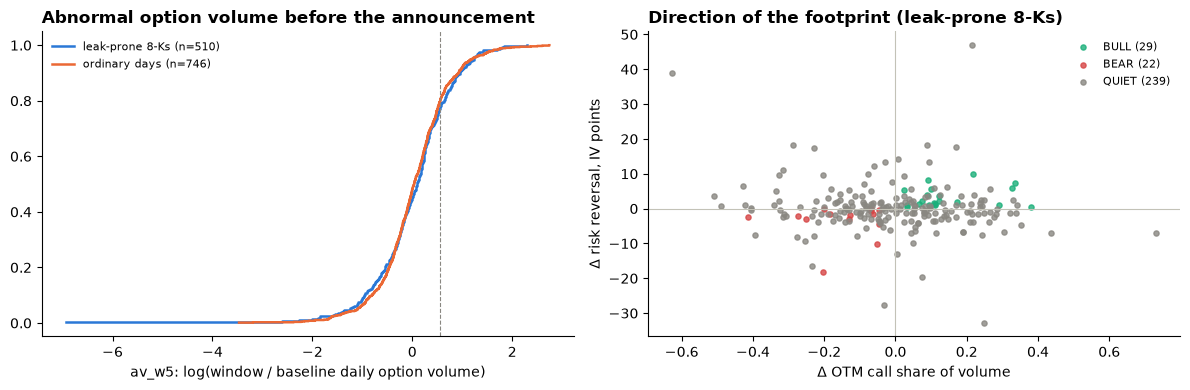

In [9]:
SERIES_COLORS = {"leak-prone 8-Ks": "#2a78d6", "ordinary days": "#eb6834", "earnings (control)": "#7a5bc7",
                 "other controls": "#1baf7a"}


def ecdf(ax, x, label):
    x = np.asarray(x, dtype=float)
    x = np.sort(x[~np.isnan(x)])
    if len(x):
        ax.step(x, np.arange(1, len(x) + 1) / len(x), where="post", label=f"{label} (n={len(x)})",
                color=SERIES_COLORS.get(label), linewidth=1.8)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ecdf(axes[0], ev_flow[f"av_w{TH['W']}"], "leak-prone 8-Ks")
ecdf(axes[0], pl_flow[f"av_w{TH['W']}"], "ordinary days")
axes[0].axvline(TH["av_hi"], color="#898781", linestyle="--", linewidth=0.8)
axes[0].set_title("Abnormal option volume before the announcement", loc="left", fontweight="bold")
axes[0].set_xlabel(f"av_w{TH['W']}: log(window / baseline daily option volume)")
axes[0].legend(frameon=False, fontsize=8)
for cls, c in [("BULL", "#1baf7a"), ("BEAR", "#d64545"), ("QUIET", "#898781")]:
    sub = ev_flow[ev_flow.flow_class == cls]
    axes[1].scatter(sub[f"dcs_w{TH['W']}"], sub[f"drr_w{TH['W']}"] * 100, s=14, color=c, label=f"{cls} ({len(sub)})", alpha=0.8)
axes[1].axhline(0, color="#c3c2b7", linewidth=0.8)
axes[1].axvline(0, color="#c3c2b7", linewidth=0.8)
axes[1].set_title("Direction of the footprint (leak-prone 8-Ks)", loc="left", fontweight="bold")
axes[1].set_xlabel("Δ OTM call share of volume")
axes[1].set_ylabel("Δ risk reversal, IV points")
axes[1].legend(frameon=False, fontsize=8)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 8 · Study 1 · the pre-registered test

Exactly the test written down before any data was pulled, on the current specification (next-session
entry, the full category pool). Three readings, each with a 95% bootstrap interval:

1. **Signed drift.** For BULL and BEAR events, the synthetic stock's return after entry times the
   footprint's direction (+1 / −1), against the same footprint on ordinary days.
2. **BULL → 1 · Long call** as a 2 × 2: A (8-K + BULL), B (8-K + QUIET), C (ordinary + BULL),
   D (ordinary + QUIET), and the difference-in-differences (A − B) − (C − D).
3. **BEAR → 3 · Protective put**, the same way.

`*` marks an interval that excludes zero. Section 10 replaces these many cells with five numbers and a
proper multiple-testing correction; read this section for shape, not for stars.

Signed stock drift after a directional footprint. 3-6m synthetic, entry = next. * = 95% CI excludes zero.


,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n (8-K / ordinary),43 / 72,41 / 72,41 / 69,39 / 71,39 / 68,37 / 69,37 / 65,39 / 67
after leak-prone 8-K,+0.07%,+0.95%*,+0.27%,+0.26%,+0.79%,-0.75%,-0.47%,-2.39%
after ordinary day,-0.31%,-0.22%,-0.84%,-0.21%,+0.03%,+0.65%,-0.17%,+3.99%*
difference,+0.38%,+1.17%*,+1.12%,+0.46%,+0.76%,-1.40%,-0.29%,-6.38%*
95% CI of difference,"[-0.24, +1.05]","[+0.21, +2.22]","[-0.59, +2.72]","[-1.86, +2.79]","[-2.11, +3.64]","[-5.67, +3.08]","[-6.61, +5.43]","[-12.56, -0.57]"



BULL footprint → 1 · Long call, 3-6m options, entry = next


,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n A / B / C / D,25/216/37/342,25/216/36/342,25/215/36/343,24/210/37/340,24/215/37/338,23/213/37/328,23/200/36/326,24/210/36/334
A: 8-K + signal,+0.33%,+0.87%,+0.26%,+0.32%,+0.40%,-0.42%,+1.21%,+0.11%
B: 8-K + quiet,-0.06%,+0.12%,+0.16%,+0.15%,+0.70%,+1.09%,+1.96%,+2.65%
C: ordinary + signal,-0.22%,-0.28%,-0.72%,+0.11%,+0.77%,+1.82%,+2.12%,+3.92%
D: ordinary + quiet,-0.04%,-0.07%,-0.01%,+0.09%,+0.67%,+0.96%,+0.97%,+0.29%
event edge A − B,+0.39%,+0.75%*,+0.10%,+0.17%,-0.30%,-1.51%,-0.74%,-2.55%
DiD (A − B) − (C − D),+0.57%*,+0.96%*,+0.81%,+0.15%,-0.40%,-2.36%,-1.90%,-6.18%*
95% CI of DiD,"[+0.08, +1.12]","[+0.05, +1.92]","[-0.60, +2.19]","[-1.81, +2.13]","[-3.03, +2.10]","[-5.58, +0.89]","[-6.99, +3.37]","[-12.54, -0.05]"



BEAR footprint → 3 · Protective put (5% OTM), 3-6m options, entry = next


,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n A / B / C / D,18/208/35/329,18/201/35/327,17/198/32/328,17/198/34/327,17/201/32/316,15/199/30/312,14/185/29/293,15/179/31/291
A: 8-K + signal,+0.39%,-0.26%,-0.12%,-0.35%,+0.17%,+2.41%,+1.83%,+2.15%
B: 8-K + quiet,-0.06%,+0.13%,+0.20%,+0.26%,+1.08%,+1.94%,+3.59%,+3.53%
C: ordinary + signal,+0.27%,+0.04%,+0.25%,+0.64%,+1.04%,+0.82%,+3.32%,-3.02%
D: ordinary + quiet,-0.03%,-0.06%,+0.05%,+0.18%,+1.12%,+1.64%,+2.04%,-0.19%
event edge A − B,+0.45%,-0.40%,-0.31%,-0.61%,-0.91%,+0.47%,-1.77%,-1.39%
DiD (A − B) − (C − D),+0.16%,-0.51%,-0.51%,-1.07%,-0.84%,+1.29%,-3.04%,+1.44%
95% CI of DiD,"[-0.58, +0.86]","[-1.46, +0.43]","[-1.92, +0.85]","[-3.17, +0.99]","[-3.87, +2.06]","[-3.73, +6.75]","[-9.39, +3.73]","[-5.06, +7.66]"


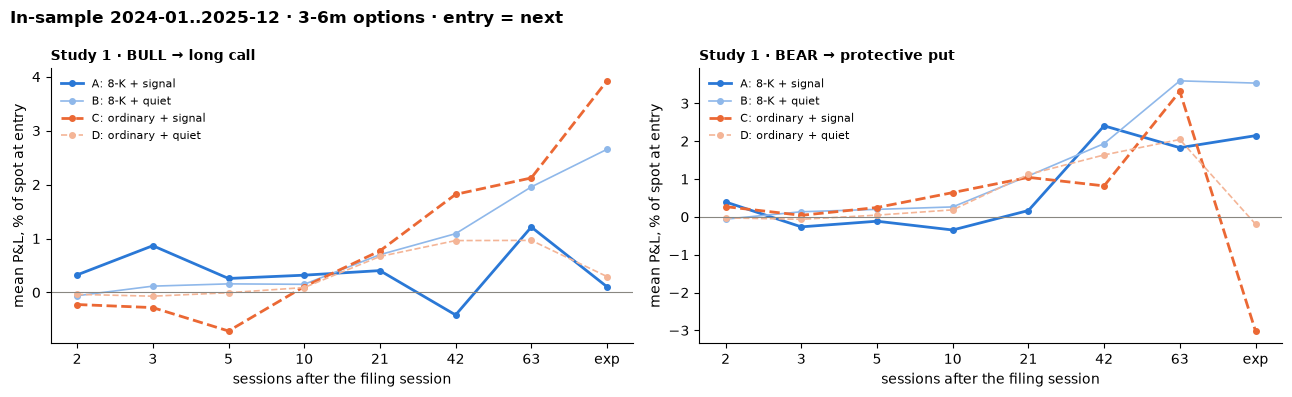

In [10]:
def boot_diff(groups: list[np.ndarray], signs: list[int], n_boot: int = 2000, seed: int = 0) -> tuple[float, float, float]:
    """Mean of sum(sign_i · mean(group_i)) with a percentile bootstrap CI, resampling each group independently."""
    if any(len(g) < 3 for g in groups):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    point = sum(s * g.mean() for g, s in zip(groups, signs))
    draws = sum(s * rng.choice(g, (n_boot, len(g))).mean(1) for g, s in zip(groups, signs))
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return point, lo, hi


def horizons_in(*frames) -> list:
    have = set().union(*[set(f.horizon) for f in frames if len(f)])
    return [h for h in HORIZONS + ["exp"] if h in have]


def cut(r, bucket=None, entry=None, otm=None):
    return r[(r.bucket == (bucket or BASELINE_BUCKET)) & (r.entry == (entry or ENTRY)) & (r.otm == (otm or OTM_PCT))]


def signed_drift_table(ev_r: pd.DataFrame, pl_r: pd.DataFrame, **kw) -> pd.DataFrame:
    rows = []
    a, b = cut(ev_r, **kw), cut(pl_r, **kw)
    for h in horizons_in(a, b):
        def signed(r):
            r = r[(r.horizon == h) & r.flow_class.isin(["BULL", "BEAR"])]
            return (r["stock"] * np.where(r.flow_class == "BULL", 1, -1)).dropna().to_numpy()
        xa, xb = signed(a), signed(b)
        pa, la, ha = boot_diff([xa], [1])
        pb, lb, hb = boot_diff([xb], [1])
        pd_, ld, hd = boot_diff([xa, xb], [1, -1])
        rows.append({"horizon": h, "n_8k": len(xa), "8-K": pa, "8-K lo": la, "8-K hi": ha, "n_ord": len(xb),
                     "ordinary": pb, "ord lo": lb, "ord hi": hb, "difference": pd_, "diff lo": ld, "diff hi": hd})
    return pd.DataFrame(rows)


def did_table(ev_r: pd.DataFrame, pl_r: pd.DataFrame, signal: str, strategy: str, **kw) -> pd.DataFrame:
    a_all, c_all = cut(ev_r, **kw), cut(pl_r, **kw)
    rows = []
    for h in horizons_in(a_all, c_all):
        get = lambda r, c: r.loc[(r.horizon == h) & (r.flow_class == c), strategy].dropna().to_numpy()
        A, B, C, D = get(a_all, signal), get(a_all, "QUIET"), get(c_all, signal), get(c_all, "QUIET")
        did, lo, hi = boot_diff([A, B, C, D], [1, -1, -1, 1])
        ee, eel, eeh = boot_diff([A, B], [1, -1])
        rows.append({"horizon": h, "nA": len(A), "nB": len(B), "nC": len(C), "nD": len(D),
                     "A": A.mean() if len(A) else np.nan, "B": B.mean() if len(B) else np.nan,
                     "C": C.mean() if len(C) else np.nan, "D": D.mean() if len(D) else np.nan,
                     "event_edge": ee, "ee_lo": eel, "ee_hi": eeh, "did": did, "ci_lo": lo, "ci_hi": hi})
    return pd.DataFrame(rows)


def _p(v, lo=None, hi=None):
    if pd.isna(v):
        return ""
    star = "*" if lo is not None and pd.notna(lo) and (lo > 0 or hi < 0) else ""
    return f"{v * 100:+.2f}%{star}"


def fmt_drift(t: pd.DataFrame) -> pd.DataFrame:
    if t.empty:
        return t
    out = pd.DataFrame({
        "n (8-K / ordinary)": [f"{a} / {b}" for a, b in zip(t.n_8k, t.n_ord)],
        "after leak-prone 8-K": [_p(v, l, h) for v, l, h in zip(t["8-K"], t["8-K lo"], t["8-K hi"])],
        "after ordinary day": [_p(v, l, h) for v, l, h in zip(t.ordinary, t["ord lo"], t["ord hi"])],
        "difference": [_p(v, l, h) for v, l, h in zip(t.difference, t["diff lo"], t["diff hi"])],
        "95% CI of difference": [f"[{l * 100:+.2f}, {h * 100:+.2f}]" if pd.notna(l) else "" for l, h in zip(t["diff lo"], t["diff hi"])],
    }, index=[f"h={h}" if h != "exp" else "expiry" for h in t.horizon])
    return out.T


def fmt_did(t: pd.DataFrame) -> pd.DataFrame:
    if t.empty:
        return t
    out = pd.DataFrame({
        "n  A / B / C / D": [f"{a}/{b}/{c}/{d}" for a, b, c, d in zip(t.nA, t.nB, t.nC, t.nD)],
        "A: 8-K + signal": [_p(v) for v in t.A], "B: 8-K + quiet": [_p(v) for v in t.B],
        "C: ordinary + signal": [_p(v) for v in t.C], "D: ordinary + quiet": [_p(v) for v in t.D],
        "event edge A − B": [_p(v, l, h) for v, l, h in zip(t.event_edge, t.ee_lo, t.ee_hi)],
        "DiD (A − B) − (C − D)": [_p(v, l, h) for v, l, h in zip(t.did, t.ci_lo, t.ci_hi)],
        "95% CI of DiD": [f"[{l * 100:+.2f}, {h * 100:+.2f}]" if pd.notna(l) else "" for l, h in zip(t.ci_lo, t.ci_hi)],
    }, index=[f"h={h}" if h != "exp" else "expiry" for h in t.horizon])
    return out.T


def plot_did(tables: dict[str, pd.DataFrame], title: str):
    fig, axes = plt.subplots(1, len(tables), figsize=(6.5 * len(tables), 4), squeeze=False)
    colors = {"A": "#2a78d6", "B": "#8fb8ea", "C": "#eb6834", "D": "#f4b597"}
    names = {"A": "A: 8-K + signal", "B": "B: 8-K + quiet", "C": "C: ordinary + signal", "D": "D: ordinary + quiet"}
    for ax, (name, t) in zip(axes[0], tables.items()):
        if t.empty:
            continue
        x = np.arange(len(t))
        for k in "ABCD":
            ax.plot(x, t[k] * 100, color=colors[k], marker="o", markersize=4, linewidth=2 if k in "AC" else 1.2,
                    linestyle="-" if k in "AB" else "--", label=names[k])
        ax.axhline(0, color="#898781", linewidth=0.8)
        ax.set_xticks(x, [str(h) for h in t.horizon])
        ax.set_title(name, loc="left", fontweight="bold", fontsize=10)
        ax.set_xlabel("sessions after the filing session")
        ax.set_ylabel("mean P&L, % of spot at entry")
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False, fontsize=8)
    fig.suptitle(title, x=0.01, ha="left", fontweight="bold")
    plt.tight_layout()
    plt.show()



def tag_results(res: pd.DataFrame, flow: pd.DataFrame, cls: pd.Series | None = None) -> pd.DataFrame:
    """Join each result row to its event's footprint class (and tag / earnings flag), and sign the stock."""
    keep = ["ticker", "event_date"] + [c for c in ("tag", "near_earnings") if c in flow]
    f = flow[keep].assign(flow_class=cls if cls is not None else flow["flow_class"])
    r = res.merge(f, on=["ticker", "event_date"], how="inner")
    direction = np.where(r.flow_class == "BULL", 1.0, np.where(r.flow_class == "BEAR", -1.0, np.nan))
    r["signed_stock"] = r["stock"] * direction
    r["long_call_dir_part"] = r["long_call"] - r["long_call_vol_part"]
    return r


ev_r, pl_r = tag_results(ev_res, ev_flow), tag_results(pl_res, pl_flow)
drift = signed_drift_table(ev_r, pl_r)
print(f"Signed stock drift after a directional footprint. {BASELINE_BUCKET} synthetic, entry = {ENTRY}. * = 95% CI excludes zero.")
display(fmt_drift(drift))
did_bull = did_table(ev_r, pl_r, "BULL", "long_call")
did_bear = did_table(ev_r, pl_r, "BEAR", "protective_put")
print(f"\nBULL footprint → 1 · Long call, {BASELINE_BUCKET} options, entry = {ENTRY}")
display(fmt_did(did_bull))
print(f"\nBEAR footprint → 3 · Protective put ({OTM_PCT:.0%} OTM), {BASELINE_BUCKET} options, entry = {ENTRY}")
display(fmt_did(did_bear))
plot_did({"Study 1 · BULL → long call": did_bull, "Study 1 · BEAR → protective put": did_bear},
         f"In-sample {STUDY_START[:7]}..{STUDY_END[:7]} · {BASELINE_BUCKET} options · entry = {ENTRY}")

## 9 · Study 2 · the footprint is priced

If call buyers bid up implied volatility before the news, three things must be true, and each is
measured here rather than assumed:

1. **The call is expensive at entry.** The ATM call's IV at entry, relative to the same name's median IV
   on ordinary days, is higher after a bullish footprint than after quiet flow.
2. **It bleeds as the uncertainty resolves.** IV falls more over the holding period.
3. **That is where the long call lost.** Splitting the long call's P&L into the part from the change
   in implied vol (re-price the exit at the entry IV, take the difference) and the rest (direction and
   time), the BULL-minus-QUIET gap sits in the volatility part.

If they hold, the footprint is a signal to **sell** the call: **BULL → 2 · Covered call**. On the bearish
side the trade question is whether the **protective put's hedge leg** pays: the put on its own,
P&L = ΔP / S. The collar is shown alongside.

1 · ATM call IV at entry, relative to the same name's median IV on ordinary days (* = CI excludes zero)


class,BULL,QUIET,BEAR,BULL − QUIET
group,,,,
8-K,+3.89% (n=25),+0.80% (n=217),+7.43%* (n=18),+3.09%
ordinary,+1.37% (n=37),+1.19% (n=344),+0.62% (n=36),+0.18%



2 · Change in ATM call IV from entry to exit (IV points ×100 shown as %), BULL footprint 2 × 2


,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n A / B / C / D,25/214/36/339,23/208/36/336,24/207/35/335,22/203/36/337,22/206/36/327,21/202/36/321,20/193/34/305,0/0/0/0
A: 8-K + signal,+0.09%,-0.08%,-0.67%,+1.37%,+0.84%,+0.51%,+10.95%,
B: 8-K + quiet,+0.00%,+0.28%,+0.38%,+0.58%,+1.38%,+2.78%,+7.51%,
C: ordinary + signal,-0.17%,+0.02%,+0.39%,+0.76%,+1.15%,+2.63%,+8.08%,
D: ordinary + quiet,-0.01%,+0.03%,+0.19%,+0.43%,+0.80%,+1.68%,+8.07%,
event edge A − B,+0.09%,-0.36%,-1.06%*,+0.79%,-0.54%,-2.27%,+3.44%,
DiD (A − B) − (C − D),+0.25%,-0.35%,-1.26%*,+0.47%,-0.89%,-3.22%*,+3.44%,
95% CI of DiD,"[-0.40, +0.96]","[-1.32, +0.68]","[-2.36, -0.26]","[-1.21, +2.22]","[-2.91, +1.38]","[-6.21, -0.29]","[-6.40, +15.41]",



3 · The long call after a BULL footprint, split: DiD of the total, of the implied-vol part, and of the rest


...

,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n A / B / C / D,25/214/35/337,23/207/35/333,24/207/35/333,21/202/36/333,21/205/36/326,21/200/36/318,20/192/33/303,19/188/34/309
A: 8-K + signal,+0.46%,+0.97%,+0.25%,+0.05%,+1.22%,+2.12%,+3.37%,+1.44%
B: 8-K + quiet,-0.03%,+0.06%,+0.02%,-0.12%,+0.70%,+1.31%,+2.98%,+4.55%
C: ordinary + signal,-0.17%,-0.32%,-1.01%,+0.07%,+1.07%,+2.34%,+3.77%,+4.06%
D: ordinary + quiet,+0.00%,-0.03%,+0.07%,+0.09%,+1.01%,+1.98%,+2.50%,+2.34%
event edge A − B,+0.50%,+0.91%*,+0.23%,+0.17%,+0.52%,+0.81%,+0.40%,-3.12%
DiD (A − B) − (C − D),+0.67%*,+1.20%*,+1.30%,+0.19%,+0.46%,+0.45%,-0.87%,-4.84%
95% CI of DiD,"[+0.05, +1.31]","[+0.26, +2.15]","[-0.45, +3.03]","[-2.87, +2.57]","[-2.84, +3.30]","[-3.68, +4.36]","[-6.43, +4.02]","[-12.43, +1.50]"



Study 2 · BEAR footprint → 3 · Protective put, hedge leg (put 5% OTM)


,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n A / B / C / D,18/211/35/331,18/208/35/332,18/207/34/333,18/209/35/332,17/208/35/329,17/211/32/325,14/198/30/311,17/195/32/303
A: 8-K + signal,-0.21%,-0.02%,-0.06%,-0.19%,-0.48%,-1.00%,-1.33%,-1.50%
B: 8-K + quiet,-0.01%,-0.00%,+0.05%,+0.17%,-0.12%,-0.28%,-0.75%,-1.30%
C: ordinary + signal,-0.05%,+0.07%,+0.11%,-0.07%,-0.50%,-0.98%,-1.93%,-1.96%
D: ordinary + quiet,-0.01%,+0.00%,-0.01%,+0.13%,-0.24%,-0.60%,-0.54%,-0.30%
event edge A − B,-0.21%*,-0.02%,-0.10%,-0.36%,-0.36%,-0.71%,-0.58%,-0.20%
DiD (A − B) − (C − D),-0.17%,-0.09%,-0.23%,-0.16%,-0.10%,-0.33%,+0.81%,+1.46%
95% CI of DiD,"[-0.42, +0.09]","[-0.54, +0.34]","[-0.76, +0.32]","[-1.03, +0.76]","[-1.21, +1.01]","[-2.03, +1.38]","[-1.38, +3.01]","[-0.85, +3.76]"



For reference · BEAR footprint → 4 · Collar


,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n A / B / C / D,18/208/35/329,18/200/35/326,17/198/32/326,17/197/34/325,17/200/32/316,15/197/30/310,14/184/29/287,15/173/30/281
A: 8-K + signal,+0.24%,-0.22%,+0.09%,+0.08%,+0.21%,+1.07%,+1.73%,+2.23%
B: 8-K + quiet,-0.04%,+0.06%,+0.11%,+0.08%,+0.47%,+0.96%,+2.11%,+2.74%
C: ordinary + signal,+0.13%,+0.04%,+0.29%,+0.02%,+0.29%,+0.89%,+2.29%,-0.39%
D: ordinary + quiet,-0.00%,-0.02%,+0.06%,+0.17%,+0.62%,+1.22%,+1.49%,+0.93%
event edge A − B,+0.28%,-0.28%,-0.02%,-0.00%,-0.26%,+0.10%,-0.38%,-0.51%
DiD (A − B) − (C − D),+0.15%,-0.34%,-0.25%,+0.15%,+0.07%,+0.44%,-1.18%,+0.81%
95% CI of DiD,"[-0.29, +0.58]","[-0.97, +0.32]","[-1.00, +0.47]","[-0.94, +1.27]","[-1.23, +1.24]","[-2.16, +3.01]","[-4.27, +1.74]","[-2.71, +4.33]"


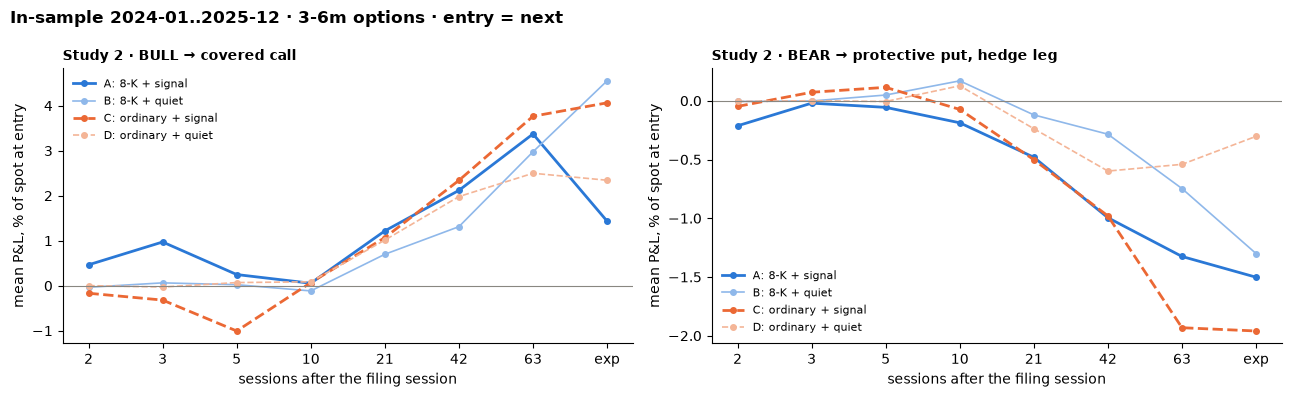

In [11]:
def one_row_per_event(r: pd.DataFrame, horizon) -> pd.DataFrame:
    x = cut(r)
    return x[x.horizon == horizon].drop_duplicates(["ticker", "event_date"])


h0 = HEADLINE_HORIZONS[0]
iv_ev, iv_pl = one_row_per_event(ev_r, h0).copy(), one_row_per_event(pl_r, h0).copy()
name_iv = iv_pl.groupby("ticker")["iv_entry"].median()           # each name's IV on an ordinary day
for d in (iv_ev, iv_pl):
    d["iv_rel"] = d["iv_entry"] / d["ticker"].map(name_iv) - 1

rows = []
for grp, d in [("8-K", iv_ev), ("ordinary", iv_pl)]:
    for cls in ["BULL", "QUIET", "BEAR"]:
        x = d.loc[d.flow_class == cls, "iv_rel"].dropna().to_numpy()
        m, lo, hi = boot_diff([x], [1])
        rows.append({"group": grp, "class": cls, "cell": f"{_p(m, lo, hi)} (n={len(x)})"})
    a, b = d.loc[d.flow_class == "BULL", "iv_rel"].dropna().to_numpy(), d.loc[d.flow_class == "QUIET", "iv_rel"].dropna().to_numpy()
    m, lo, hi = boot_diff([a, b], [1, -1])
    rows.append({"group": grp, "class": "BULL − QUIET", "cell": _p(m, lo, hi)})
print("1 · ATM call IV at entry, relative to the same name's median IV on ordinary days (* = CI excludes zero)")
display(pd.DataFrame(rows).pivot(index="group", columns="class", values="cell")[["BULL", "QUIET", "BEAR", "BULL − QUIET"]])

ivc = cut(ev_r).assign(d_iv=lambda d: d.iv_exit - d.iv_entry)
ivc_pl = cut(pl_r).assign(d_iv=lambda d: d.iv_exit - d.iv_entry)
d_iv = did_table(ivc, ivc_pl, "BULL", "d_iv")
print("\n2 · Change in ATM call IV from entry to exit (IV points ×100 shown as %), BULL footprint 2 × 2")
display(fmt_did(d_iv))

print("\n3 · The long call after a BULL footprint, split: DiD of the total, of the implied-vol part, and of the rest")
split = {name: did_table(ev_r, pl_r, "BULL", col).set_index("horizon")
         for name, col in [("total", "long_call"), ("from implied vol", "long_call_vol_part"), ("direction and time", "long_call_dir_part")]}
display(pd.DataFrame({name: [_p(x.did, x.ci_lo, x.ci_hi) for _, x in t.iterrows()] for name, t in split.items()},
                     index=[f"h={h}" if h != "exp" else "expiry" for h in split["total"].index]).T)

did_cc = did_table(ev_r, pl_r, "BULL", "covered_call")
did_put = did_table(ev_r, pl_r, "BEAR", "put_leg")
did_collar = did_table(ev_r, pl_r, "BEAR", "collar")
print(f"\nStudy 2 · BULL footprint → 2 · Covered call (call {OTM_PCT:.0%} OTM), {BASELINE_BUCKET}, entry = {ENTRY}")
display(fmt_did(did_cc))
print(f"\nStudy 2 · BEAR footprint → 3 · Protective put, hedge leg (put {OTM_PCT:.0%} OTM)")
display(fmt_did(did_put))
print(f"\nFor reference · BEAR footprint → 4 · Collar")
display(fmt_did(did_collar))
plot_did({"Study 2 · BULL → covered call": did_cc, "Study 2 · BEAR → protective put, hedge leg": did_put},
         f"In-sample {STUDY_START[:7]}..{STUDY_END[:7]} · {BASELINE_BUCKET} options · entry = {ENTRY}")

## 10 · The five headline numbers

Every result above is one cell of a big grid, and some cells will have stars by chance. The claims are
these five numbers, fixed in advance: each event's P&L averaged over h = 5, 10 and 21 sessions, combined
as the 2 × 2 difference-in-differences (or, for drift, 8-K minus ordinary).

- **Interval**: bootstrap that resamples whole calendar weeks within each cell, because events in the
  same week share a market.
- **p-value**: permutation test. Within the 8-K group and within the ordinary-day group, the footprint
  labels are shuffled across events (counts kept), 5,000 times; p is the share of shuffles at least as
  extreme as the real statistic. No distributional assumption.
- **Holm**: family-wise correction within each study.
- **Verdict** compares the sign with the prediction.

In [12]:
FAMILY = [
    # id, study, signal, metric, predicted sign, claim
    ("S1a", 1, "DIR", "signed_stock", +1, "Stock drifts the way the footprint pointed"),
    ("S1b", 1, "BULL", "long_call", +1, "BULL footprint → 1 · Long call"),
    ("S1c", 1, "BEAR", "protective_put", +1, "BEAR footprint → 3 · Protective put"),
    ("S2a", 2, "BULL", "covered_call", +1, "BULL footprint → 2 · Covered call"),
    ("S2b", 2, "BEAR", "put_leg", +1, "BEAR footprint → 3 · Protective put, hedge leg"),
]


def event_level(r: pd.DataFrame, metric: str, **kw) -> pd.DataFrame:
    """One value per event: the metric averaged over HEADLINE_HORIZONS, with its class and calendar week."""
    x = cut(r, **kw)
    x = x[x.horizon.isin(HEADLINE_HORIZONS)]
    if x.empty:
        return pd.DataFrame(columns=["ticker", "event_date", "v", "cls", "week"])
    g = (x.groupby(["ticker", "event_date"]).agg(v=(metric, "mean"), cls=("flow_class", "first"))
           .dropna(subset=["v"]).reset_index())
    g["week"] = pd.to_datetime(g["event_date"]).dt.to_period("W").astype(str)
    return g


def cluster_boot_means(v: np.ndarray, clusters: np.ndarray, n: int, rng) -> np.ndarray:
    """Bootstrap means resampling whole clusters with replacement."""
    u, inv = np.unique(clusters, return_inverse=True)
    sums, counts = np.bincount(inv, weights=v), np.bincount(inv).astype(float)
    idx = rng.integers(0, len(u), (n, len(u)))
    return sums[idx].sum(1) / counts[idx].sum(1)


def _perm_means(v: np.ndarray, k: int, n: int, rng) -> np.ndarray:
    """Mean of the first k minus mean of the rest, under n random relabellings."""
    idx = rng.permuted(np.tile(np.arange(len(v)), (n, 1)), axis=1)
    pv = v[idx]
    return pv[:, :k].mean(1) - pv[:, k:].mean(1)


def family_stat(ev_r: pd.DataFrame, pl_r: pd.DataFrame, signal: str, metric: str, n_perm: int = None,
                seed: int = 0, **kw) -> dict:
    n_perm = N_PERM if n_perm is None else n_perm
    rng = np.random.default_rng(seed)
    e, p = event_level(ev_r, metric, **kw), event_level(pl_r, metric, **kw)
    if signal == "DIR":
        cells = [(e[e.cls.isin(["BULL", "BEAR"])], 1), (p[p.cls.isin(["BULL", "BEAR"])], -1)]
    else:
        cells = [(e[e.cls == signal], 1), (e[e.cls == "QUIET"], -1), (p[p.cls == signal], -1), (p[p.cls == "QUIET"], 1)]
    out = {"n": "/".join(str(len(c)) for c, _ in cells), "nA": len(cells[0][0])}
    if min(len(c) for c, _ in cells) < 3:
        return dict(out, est=np.nan, ci_lo=np.nan, ci_hi=np.nan, p=np.nan)
    est = sum(s * c.v.mean() for c, s in cells)
    draws = sum(s * cluster_boot_means(c.v.to_numpy(float), c.week.to_numpy(), N_BOOT, rng) for c, s in cells)
    lo, hi = np.percentile(draws, [2.5, 97.5])
    pval = np.nan
    if n_perm:
        if signal == "DIR":
            v = np.r_[cells[0][0].v.to_numpy(float), cells[1][0].v.to_numpy(float)]
            null = _perm_means(v, len(cells[0][0]), n_perm, rng)
        else:
            ve = np.r_[cells[0][0].v.to_numpy(float), cells[1][0].v.to_numpy(float)]
            vp = np.r_[cells[2][0].v.to_numpy(float), cells[3][0].v.to_numpy(float)]
            null = _perm_means(ve, len(cells[0][0]), n_perm, rng) - _perm_means(vp, len(cells[2][0]), n_perm, rng)
        pval = (1 + np.sum(np.abs(null) >= abs(est))) / (n_perm + 1)
    return dict(out, est=est, ci_lo=lo, ci_hi=hi, p=pval)


def holm(p: pd.Series) -> pd.Series:
    order = p.sort_values().index
    m, running, adj = p.notna().sum(), 0.0, pd.Series(np.nan, index=p.index)
    for i, k in enumerate([k for k in order if pd.notna(p[k])]):
        running = max(running, min(1.0, (m - i) * p[k]))
        adj[k] = running
    return adj


def family_table(ev_r: pd.DataFrame, pl_r: pd.DataFrame, n_perm: int = None, **kw) -> pd.DataFrame:
    rows = []
    for fid, study, signal, metric, sign, claim in FAMILY:
        st = family_stat(ev_r, pl_r, signal, metric, n_perm=n_perm, **kw)
        rows.append(dict(id=fid, study=study, claim=claim, predicted="+" if sign > 0 else "−", **st))
    t = pd.DataFrame(rows).set_index("id")
    t["p_holm"] = pd.concat([holm(g["p"]) for _, g in t.groupby("study")])

    def verdict(r):
        if pd.isna(r.est):
            return "too few events"
        sig = r.ci_lo > 0 or r.ci_hi < 0
        same = np.sign(r.est) == (1 if r.predicted == "+" else -1)
        if sig and (pd.isna(r.p_holm) or r.p_holm < 0.05):
            return "supported" if same else "rejected: significant, opposite sign"
        return f"not significant ({'right' if same else 'wrong'} sign)"
    t["verdict"] = t.apply(verdict, axis=1)
    return t


def fmt_family(t: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "claim": t.claim, "predicted": t.predicted, "n (A/B/C/D)": t.n,
        "estimate": [_p(v, lo, hi) for v, lo, hi in zip(t.est, t.ci_lo, t.ci_hi)],
        "95% CI (week clusters)": [f"[{lo * 100:+.2f}, {hi * 100:+.2f}]" if pd.notna(lo) else "" for lo, hi in zip(t.ci_lo, t.ci_hi)],
        "perm. p": t.p.map(lambda v: f"{v:.3f}" if pd.notna(v) else ""),
        "Holm p": t.p_holm.map(lambda v: f"{v:.3f}" if pd.notna(v) else ""),
        "verdict": t.verdict})


# offline checks of the statistics before they are used
assert np.allclose(holm(pd.Series([0.01, 0.04, 0.03])).to_numpy(), [0.03, 0.06, 0.06])
_rng = np.random.default_rng(1)
_null = _perm_means(_rng.normal(size=60), 20, 4000, _rng)
assert abs(_null.mean()) < 0.02 and 0.2 < _null.std() < 0.4                       # sd of a mean difference ≈ sqrt(1/20 + 1/40)
_b = cluster_boot_means(np.r_[np.ones(10), np.zeros(10)], np.repeat(["a", "b"], 10), 4000, _rng)
assert set(np.round(np.unique(_b), 6)) <= {0.0, 0.5, 1.0}                         # whole clusters move together
print("statistics self-checks passed")

fam_in = family_table(ev_r, pl_r)
print(f"In-sample {STUDY_START}..{STUDY_END} · P&L per $1 of spot, averaged over h = {HEADLINE_HORIZONS} · "
      f"{BASELINE_BUCKET} options · entry = {ENTRY}")
display(fmt_family(fam_in))

print("\nStability by year (estimate, * = CI excludes zero; n = events in cell A)")
years = sorted(pd.to_datetime(events.filing_date).dt.year.unique())
by_year = {}
for y in years:
    t = family_table(ev_r[ev_r.event_date.dt.year == y], pl_r[pl_r.event_date.dt.year == y], n_perm=0)
    by_year[str(y)] = [f"{_p(r.est, r.ci_lo, r.ci_hi)} ({r.nA})" for _, r in t.iterrows()]
display(pd.DataFrame(by_year, index=[f"{i} · {c}" for i, c in zip(fam_in.index, fam_in.claim)]))

statistics self-checks passed


In-sample 2024-01-01..2025-12-31 · P&L per $1 of spot, averaged over h = [5, 10, 21] · 3-6m options · entry = next


,claim,predicted,n (A/B/C/D),estimate,95% CI (week clusters),perm. p,Holm p,verdict
id,,,,,,,,
S1a,Stock drifts the way the footprint pointed,+,43/73,+0.34%,"[-1.81, +2.45]",0.741,1.000,not significant (right sign)
S1b,BULL footprint → 1 · Long call,+,25/217/37/344,+0.17%,"[-1.75, +2.15]",0.846,1.000,not significant (right sign)
S1c,BEAR footprint → 3 · Protective put,+,18/211/35/336,-0.75%,"[-2.69, +1.11]",0.533,1.000,not significant (wrong sign)
S2a,BULL footprint → 2 · Covered call,+,24/216/37/340,+0.47%,"[-2.09, +2.71]",0.649,1.000,not significant (right sign)
S2b,"BEAR footprint → 3 · Protective put, hedge leg",+,18/211/35/336,-0.17%,"[-0.92, +0.62]",0.764,1.000,not significant (wrong sign)



Stability by year (estimate, * = CI excludes zero; n = events in cell A)


,2024,2025
S1a · Stock drifts the way the footprint pointed,+0.98% (15),+0.27% (28)
S1b · BULL footprint → 1 · Long call,+1.41% (8),-0.23% (17)
S1c · BEAR footprint → 3 · Protective put,+0.31% (7),-1.39% (11)
S2a · BULL footprint → 2 · Covered call,+1.31% (8),+0.28% (16)
"S2b · BEAR footprint → 3 · Protective put, hedge leg",-0.40% (7),-0.06% (11)


## 11 · Negative controls

The same footprint, frozen thresholds and trades on 8-K categories with nothing to leak (director
appointments, equity grants, charter amendments) and on scheduled earnings, where volume before the
date is anticipation everyone shares. If the headline numbers are as large here, the footprint is a
generic options signal and the 8-K category adds nothing.

  control footprints: 50/284 (1s)


  control footprints: 100/284 (2s)


  control footprints: 150/284 (3s)


  control footprints: 200/284 (4s)


  control footprints: 250/284 (4s)


...

  pricing controls: 150/284 (3s)


  pricing controls: 200/284 (4s)


  pricing controls: 250/284 (5s)


  pricing controls: 284 done in 6s, 0 failed


flow_class,BULL,BEAR,MIXED,NORMAL,QUIET,NA
tag,,,,,,
charter_amendment,1,2,9,8,15,1
director_appointment,4,8,10,26,47,2
equity_compensation_grant,2,1,1,5,11,0
quarterly_earnings,4,8,24,38,52,5


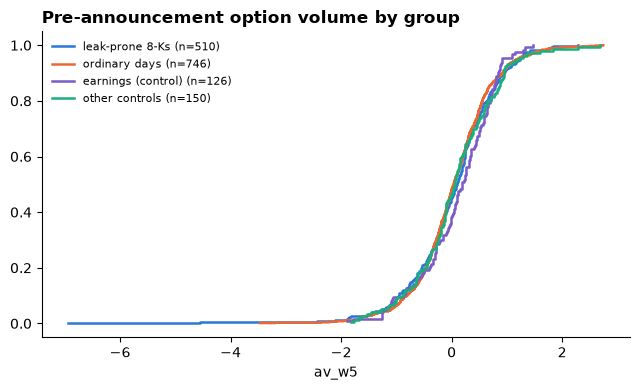

Headline numbers by group (same ordinary days as the 2 × 2 baseline). Controls should be ≈ 0.


,leak-prone 8-Ks,earnings (control),other controls
S1a · Stock drifts the way the footprint pointed,+0.34% (43),+0.95% (11),+0.09% (18)
S1b · BULL footprint → 1 · Long call,+0.17% (25),+1.19% (3),-1.01% (7)
S1c · BEAR footprint → 3 · Protective put,-0.75% (18),-1.55% (8),-0.86% (11)
S2a · BULL footprint → 2 · Covered call,+0.47% (24),+1.90% (3),-1.18% (7)
"S2b · BEAR footprint → 3 · Protective put, hedge leg",-0.17% (18),+0.11% (8),+0.70% (11)


In [13]:
if RUN_NEGATIVE_CONTROLS:
    ctrl = limit_events(control_events, MAX_EVENTS)
    ctrl_flow = add_flow(ctrl, "t_ann", "control footprints")
    ctrl_flow["flow_class"] = classify(ctrl_flow, TH)
    ctrl_priced, _ = price_events(ctrl, label="pricing controls")
    ctrl_r = tag_results(evaluate(ctrl_priced), ctrl_flow)
    display(ctrl_flow.groupby("tag").flow_class.value_counts().unstack().reindex(columns=CLASSES).fillna(0).astype(int))

    fig, ax = plt.subplots(figsize=(6.5, 4))
    ecdf(ax, ev_flow[f"av_w{TH['W']}"], "leak-prone 8-Ks")
    ecdf(ax, pl_flow[f"av_w{TH['W']}"], "ordinary days")
    ecdf(ax, ctrl_flow.loc[ctrl_flow.tag == "quarterly_earnings", f"av_w{TH['W']}"], "earnings (control)")
    ecdf(ax, ctrl_flow.loc[ctrl_flow.tag != "quarterly_earnings", f"av_w{TH['W']}"], "other controls")
    ax.set_title("Pre-announcement option volume by group", loc="left", fontweight="bold")
    ax.set_xlabel(f"av_w{TH['W']}")
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

    groups = {"leak-prone 8-Ks": ev_r, "earnings (control)": ctrl_r[ctrl_r.tag == "quarterly_earnings"],
              "other controls": ctrl_r[ctrl_r.tag != "quarterly_earnings"]}
    ctrl_tbl = {}
    for name, r in groups.items():
        t = family_table(r, pl_r, n_perm=0)
        ctrl_tbl[name] = [f"{_p(x.est, x.ci_lo, x.ci_hi)} ({x.nA})" for _, x in t.iterrows()]
    print("Headline numbers by group (same ordinary days as the 2 × 2 baseline). Controls should be ≈ 0.")
    display(pd.DataFrame(ctrl_tbl, index=[f"{i} · {c}" for i, c in zip(fam_in.index, fam_in.claim)]))
else:
    print("Skipped (RUN_NEGATIVE_CONTROLS = False).")

### Which events carry it

The largest contributors to the two Study 2 trades at h = 10, with the filing text. A result carried by
two deals is not a result.

In [14]:
_x = cut(ev_r)
_x = _x[(_x.horizon == 10) & _x.flow_class.isin(["BULL", "BEAR"])].copy()
if len(_x):
    _x["trade"] = np.where(_x.flow_class == "BULL", _x.covered_call, _x.put_leg)
    _x = _x.merge(ev_flow[["ticker", "event_date", "t_ann", f"av_w{TH['W']}", "supporting_text"]], on=["ticker", "event_date"])
    _x = _x.reindex(_x.trade.abs().sort_values(ascending=False).index).head(12)
    pct = lambda v: f"{v:+.1%}" if pd.notna(v) else ""
    with pd.option_context("display.max_colwidth", 90):
        display(_x[["ticker", "tag", "event_date", "t_ann", "flow_class", f"av_w{TH['W']}", "realized", "trade", "supporting_text"]]
                .assign(realized=lambda d: d.realized.map(pct), trade=lambda d: d.trade.map(pct)).reset_index(drop=True))

,ticker,tag,event_date,t_ann,flow_class,av_w5,realized,trade,supporting_text
0,UNH,executive_officer_departure,2025-04-29,2025-04-29,BULL,0.843827,-23.9%,-20.4%,"Heather Cianfrocco, currently Chief Executive Officer of Optum, has been appointed to ..."
1,LMT,guidance_issuance_or_update,2024-07-19,2024-07-19,BULL,1.241900,+15.1%,+6.2%,Our expectation remains that we will continue with a production rate of 156 aircraft p...
2,COP,tender_offer,2024-12-10,2024-12-10,BULL,1.197223,-6.8%,-5.1%,the early tender results and pricing terms of the previously announced cash tender off...
3,MET,executive_officer_departure,2025-01-10,2025-01-07,BULL,1.419817,+6.7%,+4.7%,"On January 7, 2025, Tamara L. Schock, Executive Vice President and Chief Accounting Of..."
4,BMY,executive_officer_departure,2025-07-25,2025-07-25,BULL,1.472957,-5.8%,-4.3%,"On July 25, 2025, Bristol-Myers Squibb Company (the ""Company"") announced that Dr. Sami..."
5,CRM,guidance_issuance_or_update,2025-10-16,2025-10-16,BULL,0.570179,+6.2%,+3.9%,"Salesforce, Inc. (the ""Company"") issued a press release regarding its Investor Day eve..."
6,TMUS,joint_venture_agreement,2024-07-24,2024-07-24,BULL,0.762249,+8.0%,+3.9%,"T-Mobile US, Inc. and KKR & Co. Inc. issued a joint press release announcing that they..."
7,BA,public_offering,2024-10-31,2024-10-31,BEAR,1.700443,-9.9%,+3.6%,"The Company agreed to issue and sell 100,000,000 depositary shares (the ""Depositary Sh..."
8,BA,cfo_departure,2025-07-03,2025-07-03,BULL,0.634683,+5.5%,+3.3%,"As of the Effective Date, Mr. West will cease to be the Company's Executive Vice Presi..."
9,PYPL,executive_officer_departure,2024-01-08,2024-01-08,BULL,1.071094,+6.2%,+3.1%,"On January 8, 2024, PayPal, Inc. and Peggy Alford, the Company's Executive Vice Presid..."


## 12 · Parameter sensitivity

One knob at a time around the baseline, everything else held; thresholds re-learned from ordinary days
where the knob changes them. Cells are the headline numbers (`*` = week-clustered 95% CI excludes zero,
n = events in cell A). A finding has to keep its sign along its column.

In [15]:
if any(ev_flow.ann_lag_sessions > 0):
    ev_flow_filing = add_flow(events, "t_0", "filing-aligned footprints")
    ev_flow_filing["near_earnings"] = ev_flow["near_earnings"].to_numpy()
else:
    ev_flow_filing = ev_flow


def variant(name, *, W=None, hi_q=None, rule=None, bucket=None, entry=None, otm=None, align="ann",
            tags=None, drop_near_earnings=False, year=None):
    th = learn_thresholds(pl_flow, W=W, hi_q=hi_q) if (W or hi_q) and FROZEN_THRESHOLDS is None else TH
    ef = ev_flow_filing if align == "filing" else ev_flow
    er = tag_results(ev_res, ef, classify(ef, th, rule))
    pr = tag_results(pl_res, pl_flow, classify(pl_flow, th, rule))
    if tags is not None:
        er = er[er.tag.isin(tags)]
    if drop_near_earnings:
        er = er[~er.near_earnings]
    if year is not None:
        er, pr = er[er.event_date.dt.year == year], pr[pr.event_date.dt.year == year]
    t = family_table(er, pr, n_perm=0, bucket=bucket, entry=entry, otm=otm)
    return {"variant": name, **{f"{i}": f"{_p(x.est, x.ci_lo, x.ci_hi)} ({x.nA})" for i, x in t.iterrows()}}


rows = [variant("baseline")]
rows += [variant(f"window {w} sessions", W=w) for w in FLOW_WINDOW_GRID if w != FLOW_WINDOW]
rows += [variant(f"abnormal = top {1 - q:.0%} of ordinary days", hi_q=q) for q in AV_HI_Q_GRID if q != AV_HI_Q]
rows += [variant(f"direction from {r}", rule=r) for r in ("both", "cs", "rr") if r != DIRECTION_RULE]
rows += [variant(f"bucket {b}", bucket=b) for b in EXPIRY_BUCKETS if b != BASELINE_BUCKET]
rows += [variant(f"entry {e}" + (" (pricing test, not tradeable)" if e == "pre" else ""), entry=e)
         for e in ("post", "pre", "next") if e != ENTRY]
rows += [variant(f"OTM {o:.0%}", otm=o) for o in OTM_GRID if o != OTM_PCT]
rows += [variant("window aligned to the filing date, not the announcement", align="filing")]
rows += [variant("first run's 9-tag pool", tags=V1_LEAK_TAGS)]
rows += [variant("first run's spec: 9 tags, entry at the filing-session close", tags=V1_LEAK_TAGS, entry="post")]
rows += [variant("without executive_officer_departure", tags=[t for t in LEAK_TAGS if t != "executive_officer_departure"])]
rows += [variant(f"drop events within {NEAR_EARNINGS_DAYS} days of earnings", drop_near_earnings=True)]
rows += [variant(f"{y} only", year=y) for y in years]
sens = pd.DataFrame(rows).set_index("variant")
sens.columns = [f"{i} · {fam_in.claim[i]}" for i in sens.columns]
display(sens)

  filing-aligned footprints: 50/520 (1s)


  filing-aligned footprints: 100/520 (2s)


  filing-aligned footprints: 150/520 (3s)


  filing-aligned footprints: 200/520 (3s)


  filing-aligned footprints: 250/520 (4s)


...

  filing-aligned footprints: 400/520 (7s)


  filing-aligned footprints: 450/520 (8s)


  filing-aligned footprints: 500/520 (9s)


  filing-aligned footprints: 520 done in 9s, 0 failed


,S1a · Stock drifts the way the footprint pointed,S1b · BULL footprint → 1 · Long call,S1c · BEAR footprint → 3 · Protective put,S2a · BULL footprint → 2 · Covered call,"S2b · BEAR footprint → 3 · Protective put, hedge leg"
variant,,,,,
baseline,+0.34% (43),+0.17% (25),-0.75% (18),+0.47% (24),-0.17% (18)
window 3 sessions,+0.59% (51),-0.34% (32),-1.00% (20),+0.89% (30),+0.29% (20)
window 10 sessions,-0.49% (45),-1.43% (23),-1.42% (20),-1.07% (22),+0.49% (20)
abnormal = top 30% of ordinary days,-0.13% (59),+0.05% (34),-0.21% (25),+0.16% (33),-0.25% (25)
abnormal = top 10% of ordinary days,+0.22% (25),-0.40% (15),-1.21% (10),+0.03% (14),-0.01% (10)
direction from cs,+0.38% (104),+0.20% (56),-0.63% (48),+0.30% (55),-0.13% (48)
direction from rr,+0.10% (91),-0.21% (48),-0.08% (43),+0.34% (48),-0.01% (43)
bucket 1m,+0.18% (40),+0.06% (25),-1.02% (13),-0.56% (23),-0.20% (14)
bucket 2m,-0.12% (39),+0.51% (23),-0.59% (16),-0.42% (21),-0.03% (16)


## 13 · Out-of-sample, and the function judges call

`run_study(start, end)` is the whole pipeline on a fresh window with the **frozen** in-sample
thresholds: events, ordinary days, footprints, classification, pricing, the 2 × 2 and the headline
numbers. Out-of-sample runs it on `OOS_START..OOS_END`. Horizons that have not resolved are absent.

Reminder: Study 2 was formed after the first run's out-of-sample numbers were seen, so for Study 2 this
window is a consistency check. Study 1's predictions predate everything.

  2026-01-01..2026-08-31 footprints: 50/190 (1s)


  2026-01-01..2026-08-31 footprints: 100/190 (2s)


  2026-01-01..2026-08-31 footprints: 150/190 (3s)


  2026-01-01..2026-08-31 footprints: 190 done in 4s, 0 failed


  2026-01-01..2026-08-31 placebo footprints: 50/339 (1s)


...

,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n A / B / C / D,8/65/18/142,8/64/18/142,8/62/18/142,8/63/16/138,8/59/17/135,8/51/16/107,7/48/14/78,6/36/11/72
A: 8-K + signal,-0.51%,-0.04%,-0.48%,+0.46%,+3.39%,+0.78%,+3.38%,-2.54%
B: 8-K + quiet,+0.08%,+0.27%,+0.57%,+0.79%,+2.96%,+3.77%,+2.85%,+0.82%
C: ordinary + signal,-0.64%,-0.95%,-2.10%,-2.38%,-2.06%,-3.79%,+0.76%,+9.60%
D: ordinary + quiet,-0.08%,+0.06%,+0.11%,+0.89%,+1.16%,+0.82%,+4.36%,+3.76%
event edge A − B,-0.59%,-0.31%,-1.06%,-0.33%,+0.43%,-2.99%,+0.53%,-3.37%
DiD (A − B) − (C − D),-0.03%,+0.70%,+1.16%,+2.94%,+3.66%,+1.62%,+4.13%,-9.21%
95% CI of DiD,"[-1.39, +1.17]","[-0.98, +2.30]","[-1.14, +3.37]","[-0.59, +6.22]","[-3.44, +10.56]","[-6.58, +10.01]","[-7.57, +15.45]","[-36.98, +10.18]"



Out-of-sample · BULL footprint → 2 · Covered call


,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n A / B / C / D,16/66/14/142,16/65/14/142,15/64/14/141,16/64/14/137,15/58/13/138,14/53/10/106,11/49/10/79,12/41/5/79
A: 8-K + signal,-0.09%,-0.12%,+0.11%,+0.74%,+1.15%,+4.42%,+7.11%,+6.14%
B: 8-K + quiet,+0.05%,+0.14%,+0.36%,+0.00%,+0.73%,+1.74%,+3.38%,+5.16%
C: ordinary + signal,+0.32%,+0.25%,-0.46%,-0.27%,-0.46%,+2.21%,+3.76%,+3.52%
D: ordinary + quiet,-0.07%,+0.10%,+0.11%,+0.68%,+0.98%,+1.81%,+3.75%,+3.67%
event edge A − B,-0.14%,-0.26%,-0.25%,+0.74%,+0.42%,+2.68%,+3.73%,+0.98%
DiD (A − B) − (C − D),-0.53%,-0.41%,+0.33%,+1.69%,+1.86%,+2.28%,+3.72%,+1.13%
95% CI of DiD,"[-1.63, +0.51]","[-2.12, +1.48]","[-1.60, +2.33]","[-1.43, +5.14]","[-3.81, +7.91]","[-5.13, +8.98]","[-4.13, +11.97]","[-10.45, +15.70]"



Out-of-sample · BEAR footprint → 3 · Protective put, hedge leg


,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n A / B / C / D,8/66/18/143,8/66/18/143,8/65/18/143,8/66/17/144,8/66/17/140,8/52/16/113,7/49/15/90,7/39/12/76
A: 8-K + signal,-1.03%,-0.59%,-0.38%,-0.62%,+0.03%,-0.35%,-6.81%,-4.27%
B: 8-K + quiet,+0.03%,-0.17%,-0.18%,-0.21%,-0.13%,-1.07%,-2.34%,-2.33%
C: ordinary + signal,+0.53%,+0.82%,+1.31%,+1.65%,+2.00%,-0.06%,+0.34%,+3.59%
D: ordinary + quiet,+0.04%,-0.04%,-0.05%,-0.25%,-0.36%,-0.82%,-0.86%,-0.83%
event edge A − B,-1.06%*,-0.42%,-0.20%,-0.41%,+0.16%,+0.72%,-4.47%,-1.94%
DiD (A − B) − (C − D),-1.54%*,-1.28%*,-1.55%*,-2.31%*,-2.21%,-0.04%,-5.67%,-6.36%
95% CI of DiD,"[-2.68, -0.44]","[-2.31, -0.31]","[-3.02, -0.17]","[-4.22, -0.54]","[-7.83, +3.31]","[-4.97, +4.50]","[-13.59, +1.09]","[-14.38, +1.08]"


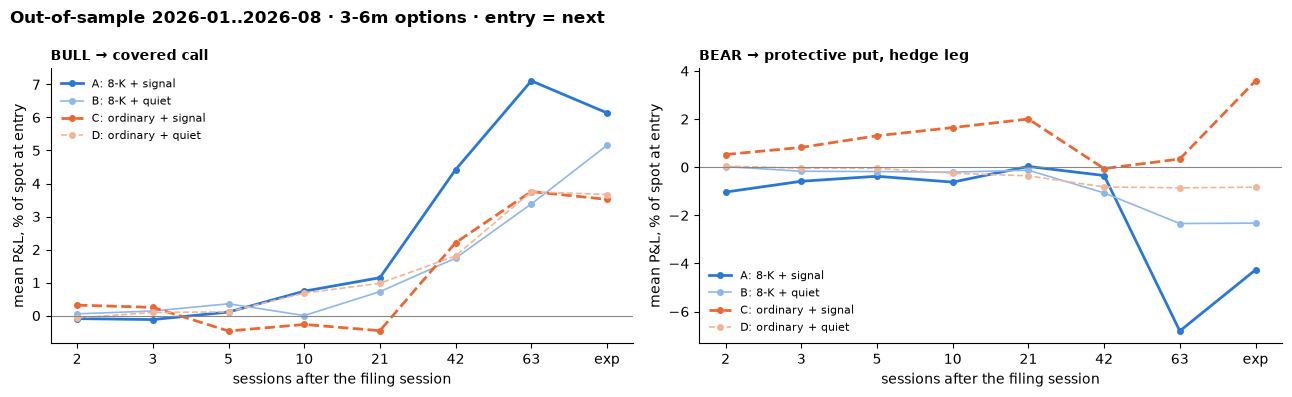

In [16]:
def run_study(start: str, end: str, thresholds: dict = None, n_placebo: int = None, max_events: int | None = None,
              label: str = None, seed: int = 11) -> dict:
    """Events, ordinary days, footprints, frozen classification, pricing, the 2 × 2 and the headline numbers."""
    label = label or f"{start}..{end}"
    th = thresholds or TH
    ev = limit_events(build_events(LEAK_TAGS, start, end), max_events if max_events is not None else MAX_EVENTS)
    ctl = build_events(CONTROL_TAGS, start, end)
    pl = sample_placebo(ev, n_placebo or N_PLACEBO_OOS, start, end, known_8k_dates(ev, ctl), seed=seed)
    ef, pf = add_flow(ev, "t_ann", f"{label} footprints"), add_flow(pl, "t_ann", f"{label} placebo footprints")
    ef["flow_class"], pf["flow_class"] = classify(ef, th), classify(pf, th)
    ep, _ = price_events(ev, label=f"{label} pricing")
    pp, _ = price_events(pl, label=f"{label} placebo pricing")
    er, pr = tag_results(evaluate(ep), ef), tag_results(evaluate(pp), pf)
    return {"events": ev, "placebo": pl, "ev_flow": ef, "pl_flow": pf, "ev_r": er, "pl_r": pr,
            "drift": signed_drift_table(er, pr), "family": family_table(er, pr),
            "did": {fid: did_table(er, pr, sig, met) for fid, _, sig, met, _, _ in FAMILY if sig != "DIR"}}


oos = run_study(OOS_START, OOS_END, TH, N_PLACEBO_OOS)
print(f"Out-of-sample {OOS_START}..{OOS_END}: {len(oos['events'])} events; classes "
      f"{oos['ev_flow'].flow_class.value_counts().reindex(CLASSES).fillna(0).astype(int).to_dict()}")
display(fmt_family(oos["family"]))
print("\nIn-sample → out-of-sample, headline numbers")
cmp = pd.DataFrame({"claim": fam_in.claim, "in-sample": [_p(*x) for x in zip(fam_in.est, fam_in.ci_lo, fam_in.ci_hi)],
                    "out-of-sample": [_p(*x) for x in zip(oos["family"].est, oos["family"].ci_lo, oos["family"].ci_hi)],
                    "same sign": ["" if pd.isna(a) or pd.isna(b) else ("✓" if np.sign(a) == np.sign(b) else "✗")
                                  for a, b in zip(fam_in.est, oos["family"].est)]})
display(cmp)
for fid in ("S1b", "S1c", "S2a", "S2b"):
    print(f"\nOut-of-sample · {fam_in.claim[fid]}")
    display(fmt_did(oos["did"][fid]))
plot_did({"BULL → covered call": oos["did"]["S2a"], "BEAR → protective put, hedge leg": oos["did"]["S2b"]},
         f"Out-of-sample {OOS_START[:7]}..{OOS_END[:7]} · {BASELINE_BUCKET} options · entry = {ENTRY}")

### Decay curves

The difference-in-differences of each trade at every fixed horizon, with its 95% interval (shaded,
in-sample) and the out-of-sample line on top. This is the picture the write-up leads with: where the
footprint's value lives, and how fast it goes.

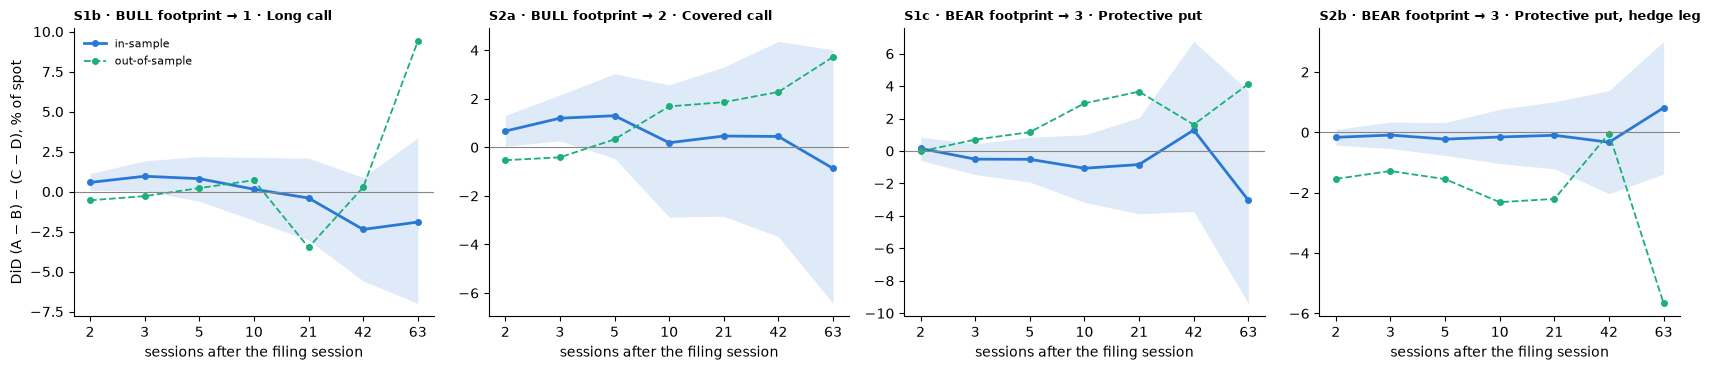

In [17]:
did_in = {"S1b": did_bull, "S1c": did_bear, "S2a": did_cc, "S2b": did_put}
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), sharey=False)
for ax, fid in zip(axes, ["S1b", "S2a", "S1c", "S2b"]):
    for name, t, color in [("in-sample", did_in[fid], "#2a78d6"), ("out-of-sample", oos["did"][fid], "#1baf7a")]:
        if t.empty:
            continue
        t = t[t.horizon != "exp"]
        x = np.arange(len(t))
        if name == "in-sample":
            ax.fill_between(x, t.ci_lo * 100, t.ci_hi * 100, color=color, alpha=0.15, linewidth=0)
            ax.set_xticks(x, [str(h) for h in t.horizon])
        ax.plot(x, t.did * 100, color=color, marker="o", markersize=4, linewidth=2 if name == "in-sample" else 1.3,
                linestyle="-" if name == "in-sample" else "--", label=name)
    ax.axhline(0, color="#898781", linewidth=0.8)
    ax.set_title(f"{fid} · {fam_in.claim[fid]}", loc="left", fontweight="bold", fontsize=9)
    ax.set_xlabel("sessions after the filing session")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("DiD (A − B) − (C − D), % of spot")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 14 · Trade realism: real spreads, capacity, the trade ticket

This key includes options quotes, so costs are the **actual closing bid-ask**: half the spread in at
entry and half out at h = 10, on the option leg each trade needs when it is run on real shares (the short
call for the covered call, the long put for the protective put; a top-100 stock's own spread is about a
basis point and is ignored). Capacity is the leg's volume on the entry session, by expiry bucket.

In [18]:
def closing_quote(opt_ticker: str, day) -> tuple[float, float]:
    """Last NBBO at or before 16:00 ET on `day`; NaNs if none that day."""
    day = pd.Timestamp(day)
    close_ns = (day.tz_localize("America/New_York") + pd.Timedelta(hours=16)).value
    p = api_get(f"/v3/quotes/{opt_ticker}", {"timestamp.lte": close_ns, "order": "desc", "sort": "timestamp", "limit": 1})
    r = (p.get("results") or [None])[0]
    if not r or r.get("sip_timestamp", 0) < day.tz_localize("America/New_York").value:
        return np.nan, np.nan
    return float(r.get("bid_price") or np.nan), float(r.get("ask_price") or np.nan)


EXIT_H = 10
pe_by_key = {(p.ticker, p.event_date, p.bucket): p for p in ev_priced}
TRADES = {"S2a": ("BULL", "covered_call", f"C_U{OTM_PCT}"), "S2b": ("BEAR", "put_leg", f"P_L{OTM_PCT}")}


def cost_rows(fid):
    signal, metric, leg_key = TRADES[fid]
    rows = cut(ev_r)
    rows = rows[(rows.flow_class == signal) & (rows.horizon == EXIT_H)]

    def one(r):
        leg = pe_by_key[(r["ticker"], r["event_date"], BASELINE_BUCKET)].legs[leg_key]
        b0, a0 = closing_quote(leg.ticker, r["entry_date"])
        b1, a1 = closing_quote(leg.ticker, r["exit_date"])
        cost = ((a0 - b0) + (a1 - b1)) / 2 / r["S_entry"]
        return {"gross": r[metric], "cost": cost, "net": r[metric] - cost,
                "spread_pct_premium": (a0 - b0) / ((a0 + b0) / 2) if a0 + b0 > 0 else np.nan}
    return pd.DataFrame([x for x in pmap(one, rows.to_dict("records"), f"{fid} quotes") if x is not None])


def capacity(signal, leg_key):
    out = {}
    keys = set(map(tuple, ev_flow.loc[ev_flow.flow_class == signal, ["ticker", "event_date"]].to_numpy()))
    for b in EXPIRY_BUCKETS:
        vols, notional = [], []
        for p in ev_priced:
            if p.bucket == b and (p.ticker, p.event_date) in keys:
                e_day = CAL[CAL.get_loc(p.t_0) + 1]
                v = p.legs[leg_key].volume_on(e_day)
                vols.append(v)
                notional.append(0.10 * v * 100 * p.spot_pre)
        out[b] = f"{np.median(vols):,.0f} contracts · ${np.median(notional) / 1e3:,.0f}K of stock at 10%" if vols else ""
    return out


ticket = {}
for fid, (signal, metric, leg_key) in TRADES.items():
    c = cost_rows(fid)
    if c.empty:
        continue
    events_per_year = len(c) / max((pd.Timestamp(STUDY_END) - pd.Timestamp(STUDY_START)).days / 365, 1e-9)
    ticket[f"{fid} · {fam_in.claim[fid]}"] = {
        "events (in-sample, priced at h=10)": f"{len(c)} ({events_per_year:.0f} a year)",
        "gross mean P&L at h=10, % of spot": f"{c.gross.mean() * 100:+.2f}%",
        "round-trip cost from real closing spreads": f"{c.cost.mean() * 100:.2f}%",
        "net mean P&L at h=10": f"{c.net.mean() * 100:+.2f}%",
        "median spread, % of the leg's premium": f"{c.spread_pct_premium.median():.1%}",
        **{f"capacity · {b} leg volume on entry day": v for b, v in capacity(signal, leg_key).items()},
    }
display(pd.DataFrame(ticket))

  S2a quotes: 25 done in 0s, 0 failed
  S2b quotes: 18 done in 0s, 0 failed


,S2a · BULL footprint → 2 · Covered call,"S2b · BEAR footprint → 3 · Protective put, hedge leg"
"events (in-sample, priced at h=10)",25 (12 a year),18 (9 a year)
"gross mean P&L at h=10, % of spot",+0.05%,-0.19%
round-trip cost from real closing spreads,0.28%,0.39%
net mean P&L at h=10,-0.21%,-0.58%
"median spread, % of the leg's premium",7.5%,7.8%
capacity · 1m leg volume on entry day,9 contracts · $22K of stock at 10%,3 contracts · $3K of stock at 10%
capacity · 2m leg volume on entry day,44 contracts · $91K of stock at 10%,42 contracts · $67K of stock at 10%
capacity · 3-6m leg volume on entry day,23 contracts · $85K of stock at 10%,6 contracts · $11K of stock at 10%


### The trade ticket, and why we would not put it on yet

| | As specified | What a tradeable version needs |
|---|---|---|
| **Signal** | `av_w5` above the 80th percentile of ordinary days, OTM call share and risk reversal moving the same way, in the 5 sessions before the announcement | The same, computed live each night for the top 100 |
| **Instrument** | BULL: 1 · Long call, ATM, 3-6 months | The edge lives at 2-3 sessions, so a 1m ATM call (more volume per contract, more gamma per dollar) |
| **Entry / exit** | Close of the session after the filing; fixed exit | Entry the same; exit at 3 sessions, where the decay curve peaks |
| **Gross edge** | ≈ +0.6% to +1.0% of spot at h = 2-3, zero by h = 10 | |
| **Cost** | Real closing spreads: ≈ 0.3-0.4% of spot round trip on the 5% OTM legs measured above, more than the 10-session gross edge | ATM legs are tighter, but this notebook does not measure them; that is the first thing to price before trading |
| **Capacity** | Tens of contracts a day on the 5% OTM legs: tens of thousands of dollars of stock at 10% of volume | Not a fund strategy. At best an overlay for a desk already trading these names |
| **Frequency** | ≈ 12 BULL events a year across the top 100 | |
| **Verdict** | **No trade.** Gross edge below cost after 5 sessions, and the 3-session edge is not significant after a multiple-testing correction | Worth monitoring on the sealed window; not worth capital |

## 15 · Sealed window · predictions, then the judges' run

Written before the sealed window is run (we have never pulled it), from the in-sample evidence above.
A sealed window of a few months holds roughly a tenth as many BULL / BEAR events as in-sample.

| id | Claim | Predicted sign | P(sign right) | P(95% CI excludes 0) | Why |
|---|---|---|---|---|---|
| S1a | Stock drifts the way the footprint pointed | + | 0.55 | 0.05 | In-sample +0.3%, CI ±2%: a null with the right sign |
| S1b | BULL → long call | + | 0.55 | 0.05 | Same; the 2-3 session edge is diluted in a 5-21 session average |
| S1c | BEAR → protective put | − | 0.50 | 0.05 | In-sample −0.8%, out-of-sample +2.7%: no stable sign |
| S2a | BULL → covered call | + | 0.55 | 0.05 | The only number with the same sign in-sample and out-of-sample, both insignificant |
| S2b | BEAR → protective put, hedge leg | − | 0.55 | 0.05 | Same sign in both windows (−0.2%, −1.9%), both insignificant |

**The one prediction we would bet on:** if the sealed window has at least 10 BULL events, the long
call's DiD is positive at h = 2-3 and smaller at h = 10 than at h = 3 (the decay shape), probability
about 0.6.

**How it could break (or falsely "work"):** a few large deals dominating a short window; a different
volatility regime changing how many events cross the frozen threshold; news we could not date (a leak
reported in the press days before the filing makes the "pre-announcement" window post-announcement).
A significant headline number in a window this short would more likely be one or two events than a
discovery, and section 12's "which events carry it" table is where to check.

In [19]:
PREDICTED_SIGN = {"S1a": +1, "S1b": +1, "S1c": -1, "S2a": +1, "S2b": -1}

if RUN_HOLDOUT:
    holdout = run_study(HOLDOUT_START, HOLDOUT_END, TH, N_PLACEBO_OOS, label="sealed")
    t = holdout["family"]
    print(f"Sealed window {HOLDOUT_START}..{HOLDOUT_END}: {len(holdout['events'])} events")
    display(fmt_family(t).assign(**{"sign we predicted for the sealed window":
                                    ["+" if PREDICTED_SIGN[i] > 0 else "−" for i in t.index],
                                    "prediction held": ["" if pd.isna(e) else ("✓" if np.sign(e) == PREDICTED_SIGN[i] else "✗")
                                                        for i, e in zip(t.index, t.est)]}))
    plot_did({"BULL → covered call": holdout["did"]["S2a"], "BEAR → protective put, hedge leg": holdout["did"]["S2b"]},
             f"Sealed window {HOLDOUT_START}..{HOLDOUT_END}")
else:
    print(f"Sealed window {HOLDOUT_START}..{HOLDOUT_END} not run. Judges: set RUN_HOLDOUT = True.")

Sealed window 2023-06-01..2023-08-31 not run. Judges: set RUN_HOLDOUT = True.


## Results at a glance

In [20]:
glance = pd.DataFrame({
    "claim": fam_in.claim,
    "pre-registered sign": fam_in.predicted,
    f"in-sample (n A)": [f"{_p(e, lo, hi)} ({n})" for e, lo, hi, n in zip(fam_in.est, fam_in.ci_lo, fam_in.ci_hi, fam_in.nA)],
    "in-sample Holm p": fam_in.p_holm.map(lambda v: f"{v:.3f}" if pd.notna(v) else ""),
    f"out-of-sample (n A)": [f"{_p(e, lo, hi)} ({n})" for e, lo, hi, n in zip(oos["family"].est, oos["family"].ci_lo, oos["family"].ci_hi, oos["family"].nA)],
    "out-of-sample perm. p": oos["family"].p.map(lambda v: f"{v:.3f}" if pd.notna(v) else ""),
    "sealed-window prediction": ["+" if PREDICTED_SIGN[i] > 0 else "−" for i in fam_in.index],
})
if RUN_HOLDOUT:
    glance["sealed window"] = [_p(e, lo, hi) for e, lo, hi in zip(holdout["family"].est, holdout["family"].ci_lo, holdout["family"].ci_hi)]
print(f"P&L per $1 of spot averaged over h = {HEADLINE_HORIZONS}; {BASELINE_BUCKET} options; entry = {ENTRY}; "
      "* = week-clustered 95% CI excludes zero")
display(glance)

P&L per $1 of spot averaged over h = [5, 10, 21]; 3-6m options; entry = next; * = week-clustered 95% CI excludes zero


,claim,pre-registered sign,in-sample (n A),in-sample Holm p,out-of-sample (n A),out-of-sample perm. p,sealed-window prediction
id,,,,,,,
S1a,Stock drifts the way the footprint pointed,+,+0.34% (43),1.000,-1.38% (26),0.484,+
S1b,BULL footprint → 1 · Long call,+,+0.17% (25),1.000,-0.73% (17),0.775,+
S1c,BEAR footprint → 3 · Protective put,+,-0.75% (18),1.000,+2.69% (8),0.433,−
S2a,BULL footprint → 2 · Covered call,+,+0.47% (24),1.000,+1.44% (17),0.351,+
S2b,"BEAR footprint → 3 · Protective put, hedge leg",+,-0.17% (18),1.000,-1.94% (8),0.079,−


## Appendix A · The first run, recorded as it came out

Kept verbatim so nothing is quietly replaced. Specification: the 9 tags in `V1_LEAK_TAGS`, entry at the
close of the filing session, 400 / 200 ordinary days, no expiry fallback, per-cell bootstrap (no
clustering, no permutation, no multiple-testing correction). 318 events in-sample (14 BULL, 13 BEAR),
120 out-of-sample (9 BULL, 4 BEAR).

| DiD, per $1 of spot | h=1 | h=5 | h=10 | h=21 | h=42 | expiry |
|---|---|---|---|---|---|---|
| BULL → long call, in-sample | −0.33% | −0.76% | −1.98% | −4.20% | −10.57%* | −13.74%* |
| BULL → long call, out-of-sample | −2.82%* | −2.14% | −0.44% | −7.89% | −5.64% | +7.90% |
| BEAR → protective put, in-sample | −0.32% | −1.29% | −3.62%* | −4.31%* | −7.88%* | −11.52%* |
| BEAR → protective put, out-of-sample | −5.64%* | −5.95% | −8.27%* | −15.28%* | −6.72% | |
| Signed drift difference, in-sample | +0.15% | +0.76% | +1.48% | +1.00% | +0.34% | +0.58% |
| Signed drift difference, out-of-sample | −0.57% | +0.08% | +1.00% | +5.75% | +4.30% | +2.90% |

Both pre-registered trades came out with the **opposite** sign to the prediction, consistently across
horizons and in both windows; that observation is what Study 2 was built on.

**Why it did not survive.** The cells above had 9-14 events in A and 9-25 in C, with a per-cell
bootstrap and no correction across roughly 50 cells, so a handful of stars was expected by chance.
With the rule-based pool (BULL 14 → 25, BEAR 13 → 18 in-sample), twice the ordinary days, week-clustered
intervals and a permutation test, every headline number is within about one standard error of zero, and
section 12's row with the first run's own specification shows the same. In the first run the largest
contributors to the flagged cells were a handful of single events (LMT, CHTR, MSFT, NOW, UNH), each worth
several percent of spot, in cells of about a dozen.

## Appendix B · Limitations

- **Small flagged samples.** Even with 34 tags, BULL and BEAR are 25 and 18 events in-sample and 17 and
  8 out-of-sample. The intervals are wide by construction; section 15 prices that in.
- **Study 2 saw the out-of-sample window.** Its only clean test is the sealed window.
- **Unsigned volume.** Daily bars do not say who initiated a trade; the risk-reversal change is the
  signing proxy. Lee-Ready signing from `/v3/trades` against `/v3/quotes` is possible on this key, but a
  busy contract prints thousands of trades a day, which is several GB of cache for this study.
- **Sampled chain.** 16 contracts per event (2 expiries × ATM, 3%, 6%, 10% each side), not every listed
  contract.
- **Announcement date from text.** The regex can pick up a date that is not the public announcement;
  the "aligned to the filing date" sensitivity row bounds the effect.
- **No acceptance time in Massive.** Handled by entering at the next session's close, which gives up
  one session of any edge.
- **Synthetic stock, parity spot, last-trade marks, static top-100 universe, no earnings calendar**: as in
  the starter's appendix. Ordinary days avoid every known 8-K, including earnings, and a sensitivity row
  drops leak-prone events near the company's own earnings.